# WanderStay Listings — Data Cleaning & Exploratory Analysis

This notebook loads the raw WanderStay listings dataset, inspects it, fixes data types, removes invalid records, explores the variables visually, and finally **corrects the categorical variables and handles missing values** so the DataFrame is clean and ready for the next stage of work.

## 1. Setup & Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Set a style for your plots
sns.set_theme(style="whitegrid")

## 2. Load the Dataset

Read the CSV and preview the first few rows to confirm it loaded correctly.

In [2]:
# Load the dataset
df = pd.read_csv('wanderstay_listings.csv')

# Display the first few rows to verify it loaded correctly
df.head()

,listing_id,host_id,host_since,host_is_superhost,host_listings_count,city,neighborhood,property_type,room_type,accommodates,...,amenities,distance_to_center_km,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable,availability_365,estimated_monthly_revenue,internal_quality_score,price
0,WS100859,1741,2016-06-26,t,1,Delhi,Connaught Place,Penthouse,Entire home,6,...,"{Wifi,AC,Pool,Washing Machine,TV,Heater,Pet Fr...",0.19,1,23,82.5,f,197,57789.0,59.3,"₹4,647"
1,WS103542,2132,2024-03-27,t,4,Pune,Hinjewadi,Cottage,Shared room,7,...,"{Wifi,AC,Kitchen,Parking,TV}",3.52,1,5,90.0,t,141,47279.0,14.9,"₹2,799"
2,WS103703,4530,2015-07-23,f,3,Pune,Kothrud,Apartment,Private room,5,...,"{Wifi,AC,Washing Machine,TV,Heater}",10.40,7,13,91.5,t,48,20813.0,16.2,"₹1,138"
3,WS101270,3058,2018-06-07,t,2,Bangalore,HSR Layout,Studio,Shared room,2,...,"{Wifi,AC,Kitchen,TV,Heater,Workspace}",4.86,3,16,83.0,t,150,14777.0,93.5,₹947
4,WS103190,7081,2020-02-26,f,3,Jaipur,Malviya Nagar,Villa,Entire home,2,...,"{Wifi,AC,Kitchen,Parking,Pool,TV}",2.99,7,16,74.2,t,111,62754.0,31.3,"₹3,038"


## 3. Initial Inspection

Check the structure (column names, data types, non-null counts) and the number of missing values per column.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4035 entries, 0 to 4034
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   listing_id                 4035 non-null   object 
 1   host_id                    4035 non-null   int64  
 2   host_since                 3955 non-null   object 
 3   host_is_superhost          4010 non-null   object 
 4   host_listings_count        4035 non-null   int64  
 5   city                       4035 non-null   object 
 6   neighborhood               3975 non-null   object 
 7   property_type              4035 non-null   object 
 8   room_type                  4035 non-null   object 
 9   accommodates               4035 non-null   int64  
 10  bedrooms                   3831 non-null   float64
 11  bathrooms                  3914 non-null   float64
 12  beds                       4035 non-null   int64  
 13  amenities                  4035 non-null   objec

In [4]:
# Display the count of null values for each column
df.isnull().sum()

listing_id                     0
host_id                        0
host_since                    80
host_is_superhost             25
host_listings_count            0
city                           0
neighborhood                  60
property_type                  0
room_type                      0
accommodates                   0
bedrooms                     204
bathrooms                    121
beds                           0
amenities                      0
distance_to_center_km          0
minimum_nights                 0
number_of_reviews              0
review_scores_rating         146
instant_bookable              24
availability_365               0
estimated_monthly_revenue      0
internal_quality_score         0
price                          0
dtype: int64

## 4. Fix Data Types

`host_since` is read in as text. Convert it to a proper `datetime` type so it can be used for date-based calculations later (e.g. median date imputation).

In [5]:
# Convert host_since to datetime objects
df['host_since'] = pd.to_datetime(df['host_since'])

# Verify the conversion
print(df['host_since'].dtype)

datetime64[ns]


## 5. Summary Statistics & Removing Invalid Records

Review the numeric summary, then drop physically impossible records (negative bedrooms, distance, or revenue) and re-check the statistics.

In [6]:
df.describe()

,host_id,host_since,host_listings_count,accommodates,bedrooms,bathrooms,beds,distance_to_center_km,minimum_nights,number_of_reviews,review_scores_rating,availability_365,estimated_monthly_revenue,internal_quality_score
count,4035.000000,3955,4035.000000,4035.000000,3831.000000,3914.000000,4035.000000,4035.000000,4035.000000,4035.000000,3889.000000,4035.000000,4035.000000,4035.000000
mean,5480.653284,2020-01-11 01:46:18.963337728,2.981908,4.736803,1.662490,1.499617,3.810657,4.952659,4.732094,19.933581,89.593572,179.135068,44251.930607,49.558959
min,1001.000000,2015-01-01 00:00:00,1.000000,0.000000,-1.000000,1.000000,1.000000,-3.000000,1.000000,0.000000,68.200000,0.000000,-778.000000,0.000000
25%,3344.000000,2017-07-06 12:00:00,2.000000,3.000000,1.000000,1.000000,2.000000,1.420000,1.000000,9.000000,85.200000,87.000000,17503.000000,25.200000
50%,5467.000000,2019-12-07 00:00:00,3.000000,4.000000,1.000000,1.500000,3.000000,3.480000,2.000000,19.000000,89.800000,179.000000,35435.000000,49.300000
75%,7708.000000,2022-07-03 12:00:00,4.000000,6.000000,2.000000,1.500000,5.000000,6.965000,5.000000,29.000000,94.400000,269.000000,59261.500000,74.000000
max,9996.000000,2027-03-15 00:00:00,11.000000,16.000000,8.000000,6.000000,16.000000,35.000000,1000.000000,57.000000,100.000000,365.000000,545451.000000,99.900000
std,2572.279582,NaN,1.416462,2.520244,0.950278,0.672703,2.120639,4.842621,44.413250,12.303066,6.475568,105.308856,38077.127927,28.580645


In [7]:
import pandas as pd

# Filter out the invalid data points
df = df[
    (df['bedrooms'] >= 0) & 
    (df['distance_to_center_km'] >= 0) & 
    
    (df['accommodates'] > 0) & 
    (df['minimum_nights'] <= 365) & 
    (df['host_since'] <= pd.Timestamp.today())
]

# Verify the changes
df.describe()

,host_id,host_since,host_listings_count,accommodates,bedrooms,bathrooms,beds,distance_to_center_km,minimum_nights,number_of_reviews,review_scores_rating,availability_365,estimated_monthly_revenue,internal_quality_score
count,3726.000000,3726,3726.000000,3726.000000,3726.000000,3616.000000,3726.000000,3726.000000,3726.000000,3726.000000,3591.000000,3726.000000,3726.000000,3726.000000
mean,5493.349705,2019-12-29 02:07:55.362318848,2.974503,4.747719,1.666667,1.502351,3.814278,4.967872,2.746108,19.859367,89.567224,179.327429,44193.132045,49.585024
min,1001.000000,2015-01-01 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000,0.100000,1.000000,0.000000,68.200000,0.000000,-778.000000,0.000000
25%,3353.000000,2017-07-07 12:00:00,2.000000,3.000000,1.000000,1.000000,2.000000,1.430000,1.000000,9.000000,85.200000,87.250000,17469.000000,25.225000
50%,5482.500000,2019-11-30 00:00:00,3.000000,4.000000,1.000000,1.500000,3.000000,3.480000,2.000000,19.000000,89.800000,179.000000,35293.500000,49.600000
75%,7742.750000,2022-06-20 12:00:00,4.000000,6.000000,2.000000,1.500000,5.000000,6.970000,5.000000,29.000000,94.400000,269.000000,59371.500000,74.200000
max,9996.000000,2024-12-25 00:00:00,11.000000,16.000000,8.000000,6.000000,16.000000,35.000000,7.000000,57.000000,100.000000,365.000000,545451.000000,99.900000
std,2574.595425,NaN,1.417113,2.517208,0.946629,0.671125,2.126691,4.844230,2.054938,12.284178,6.488918,105.441958,38090.850190,28.645535


Quick look at just the **mean** and **standard deviation** for each numeric column:

In [8]:
# Extract and display only the mean and standard deviation
stats = df.describe().loc[['mean', 'std']]
print(stats)

          host_id                     host_since  host_listings_count  \
mean  5493.349705  2019-12-29 02:07:55.362318848             2.974503   
std   2574.595425                            NaN             1.417113   

      accommodates  bedrooms  bathrooms      beds  distance_to_center_km  \
mean      4.747719  1.666667   1.502351  3.814278               4.967872   
std       2.517208  0.946629   0.671125  2.126691               4.844230   

      minimum_nights  number_of_reviews  review_scores_rating  \
mean        2.746108          19.859367             89.567224   
std         2.054938          12.284178              6.488918   

      availability_365  estimated_monthly_revenue  internal_quality_score  
mean        179.327429               44193.132045               49.585024  
std         105.441958               38090.850190               28.645535  


## 6. Distributions of Continuous Variables

Kernel density estimates (PDFs) for the continuous numeric variables to understand their shape and spread.

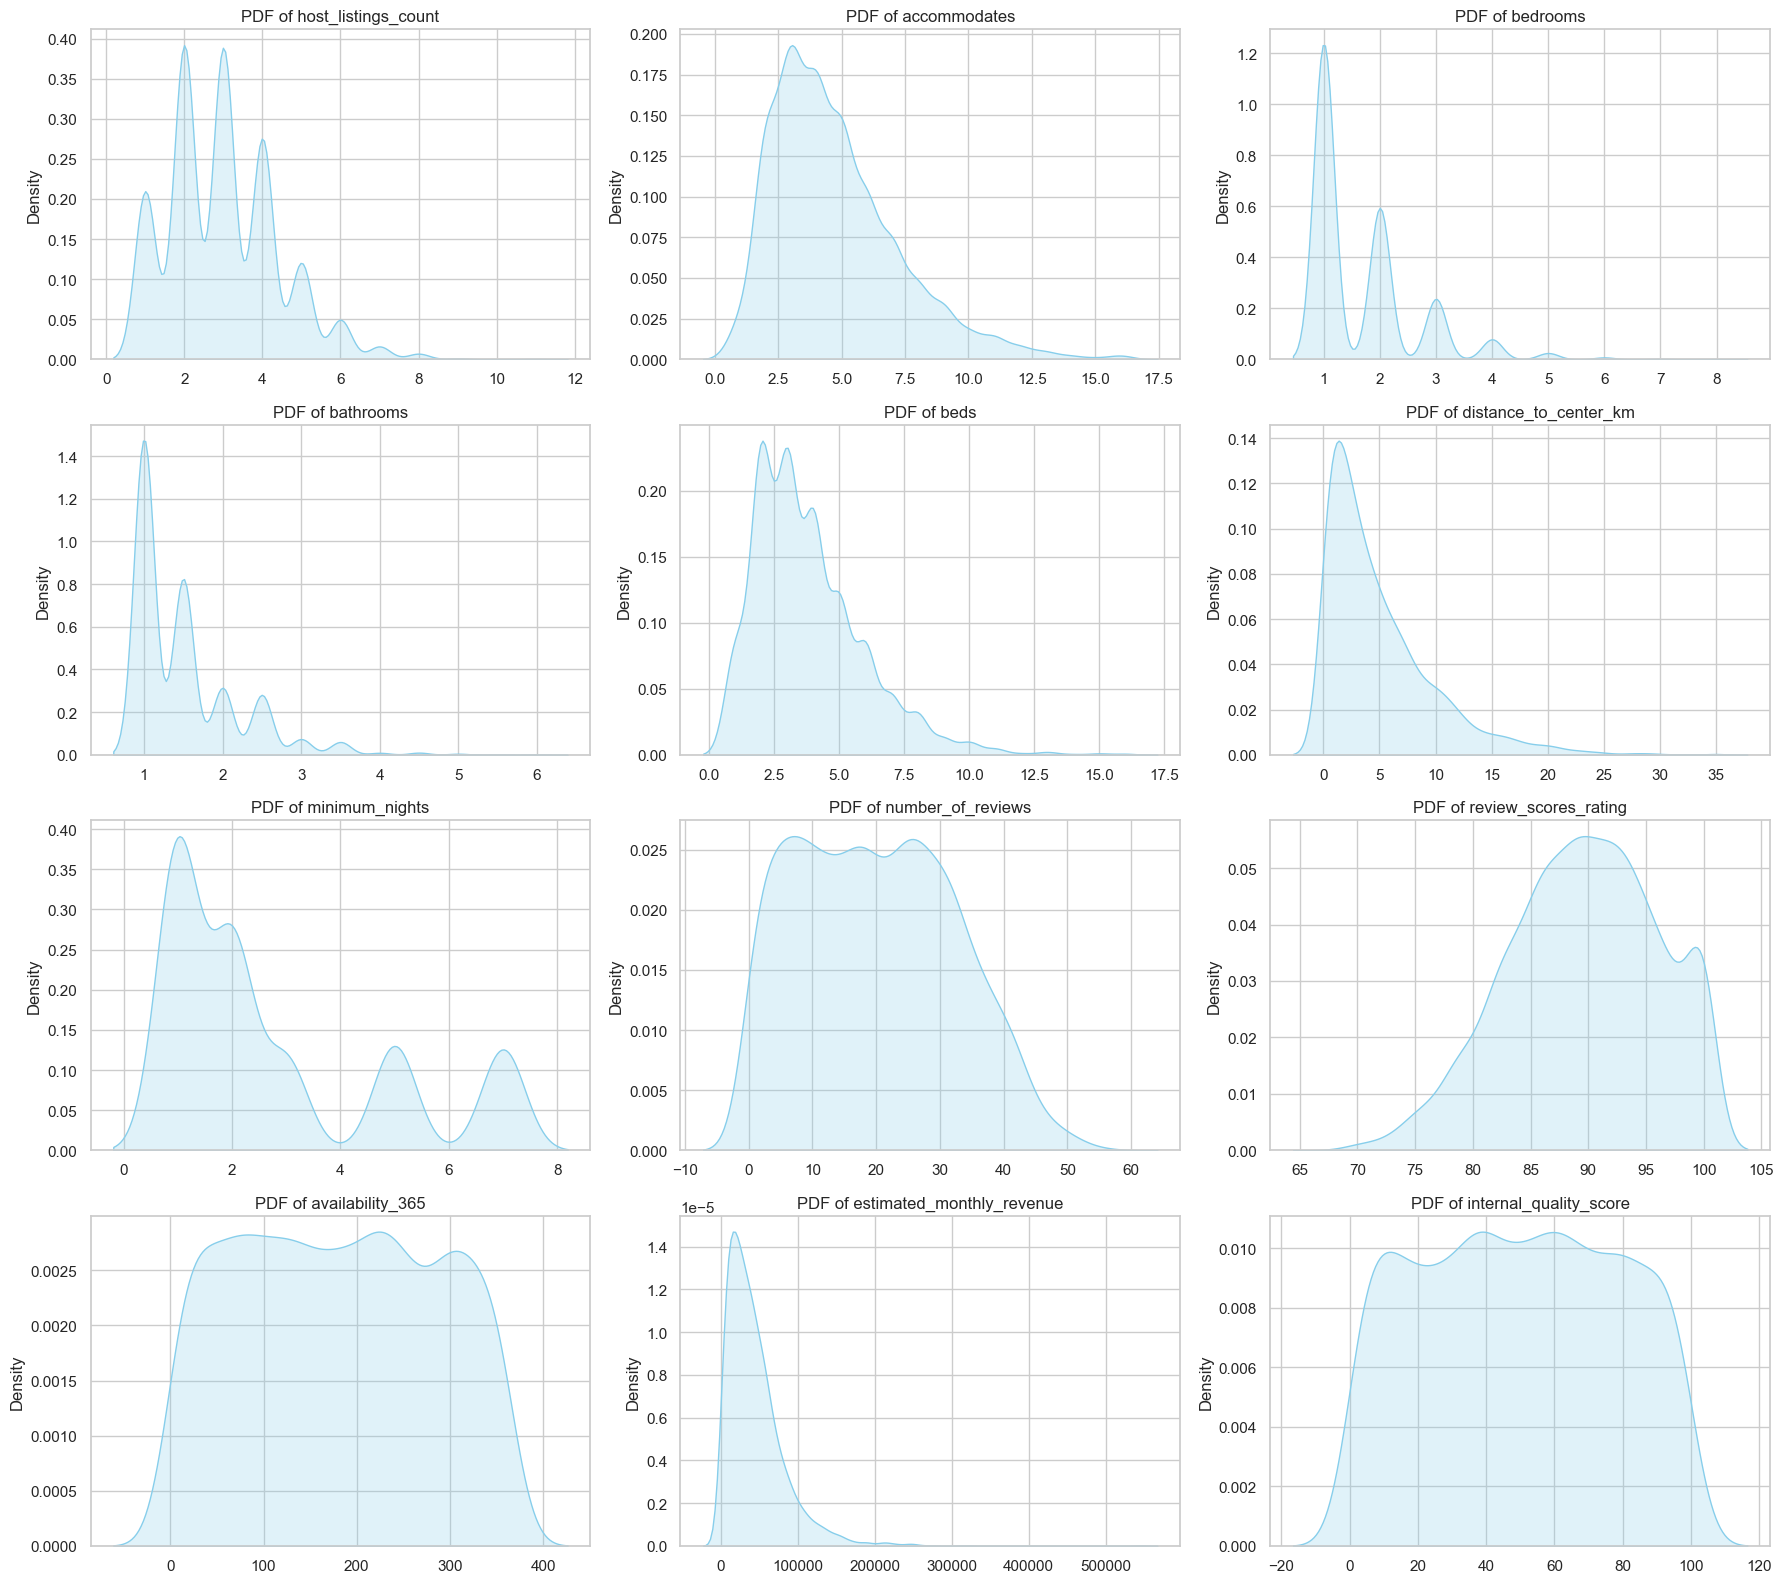

In [9]:
# Identify continuous columns (excluding IDs and categorical text)
continuous_cols = [
    'host_listings_count', 'accommodates', 'bedrooms', 'bathrooms', 'beds', 
    'distance_to_center_km', 'minimum_nights', 'number_of_reviews', 
    'review_scores_rating', 'availability_365', 'estimated_monthly_revenue', 
    'internal_quality_score'
]

# Set up the figure for subplots
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()  # Flatten the grid to make it easier to iterate

# Create a kdeplot for each column
for i, col in enumerate(continuous_cols):
    sns.kdeplot(data=df, x=col, ax=axes[i], fill=True, color='skyblue')
    axes[i].set_title(f'PDF of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

## 7. Identifying & Summarising Categorical Variables

List the text (object) columns, then summarise the genuinely categorical ones with both **counts** and **percentages** for each category.

In [10]:
# Select only columns with 'object' data type
object_cols = df.select_dtypes(include=['object']).columns.tolist()

# Display the list of object columns
print("Columns with object data type:", object_cols)

# If you want to see the first few rows of just these columns:
df[object_cols].head()

Columns with object data type: ['listing_id', 'host_is_superhost', 'city', 'neighborhood', 'property_type', 'room_type', 'amenities', 'instant_bookable', 'price']


,listing_id,host_is_superhost,city,neighborhood,property_type,room_type,amenities,instant_bookable,price
0,WS100859,t,Delhi,Connaught Place,Penthouse,Entire home,"{Wifi,AC,Pool,Washing Machine,TV,Heater,Pet Fr...",f,"₹4,647"
1,WS103542,t,Pune,Hinjewadi,Cottage,Shared room,"{Wifi,AC,Kitchen,Parking,TV}",t,"₹2,799"
2,WS103703,f,Pune,Kothrud,Apartment,Private room,"{Wifi,AC,Washing Machine,TV,Heater}",t,"₹1,138"
3,WS101270,t,Bangalore,HSR Layout,Studio,Shared room,"{Wifi,AC,Kitchen,TV,Heater,Workspace}",t,₹947
4,WS103190,f,Jaipur,Malviya Nagar,Villa,Entire home,"{Wifi,AC,Kitchen,Parking,Pool,TV}",t,"₹3,038"


In [11]:
# List of columns to analyze
cat_cols_to_analyze = ['host_is_superhost', 'city', 'neighborhood', 'property_type', 'room_type', 'instant_bookable']

for col in cat_cols_to_analyze:
    # Get counts
    counts = df[col].value_counts()
    # Get percentages
    percentages = df[col].value_counts(normalize=True) * 100
    
    # Combine into a single DataFrame
    summary = pd.DataFrame({'Count': counts, 'Percentage': percentages})
    
    # Format the percentage for better readability
    summary['Percentage'] = summary['Percentage'].map('{:.2f}%'.format)
    
    print(f"\n--- {col} Summary ---")
    print(summary)


--- host_is_superhost Summary ---
                   Count Percentage
host_is_superhost                  
f                   2595     70.12%
t                   1051     28.40%
True                  21      0.57%
False                 17      0.46%
TRUE                  17      0.46%

--- city Summary ---
            Count Percentage
city                        
Mumbai        799     21.44%
Delhi         714     19.16%
Bangalore     703     18.87%
Goa           481     12.91%
Pune          409     10.98%
Jaipur        323      8.67%
Delhi          71      1.91%
Mumbai         70      1.88%
 Bangalore     51      1.37%
PUNE           40      1.07%
GOA            37      0.99%
jaipur         28      0.75%

--- neighborhood Summary ---
                 Count Percentage
neighborhood                     
Bandra             159      4.33%
Powai              157      4.28%
Worli              144      3.92%
Connaught Place    142      3.87%
Colaba             142      3.87%
MG Road          

### 7.1. Cleaning the Categorical Variables

Standardise the boolean-style columns (`host_is_superhost`, `instant_bookable`) into true `True`/`False` values, and normalise the `city` text (trim whitespace, Title Case).

In [12]:
# ==========================================
# PART 1: CLEANING CATEGORICAL VARIABLES
# ==========================================

print("Starting categorical data cleaning...")

# 1. Clean 'host_is_superhost' and 'instant_bookable'
# Standardizing mixed boolean representations into standard Python booleans (True/False)
bool_mapping = {
    't': True, 'TRUE': True, 'True': True,
    'f': False, 'FALSE': False, 'False': False
}

df['host_is_superhost'] = df['host_is_superhost'].map(bool_mapping)
df['instant_bookable'] = df['instant_bookable'].map(bool_mapping)

# 2. Clean 'city'
# Removing leading/trailing whitespaces and standardizing to Title Case
df['city'] = df['city'].str.strip().str.title()

# ==========================================
# VERIFICATION
# ==========================================

print("\n--- Cleaned 'host_is_superhost' Summary ---")
print(df['host_is_superhost'].value_counts(dropna=False))

print("\n--- Cleaned 'instant_bookable' Summary ---")
print(df['instant_bookable'].value_counts(dropna=False))

print("\n--- Cleaned 'city' Summary ---")
print(df['city'].value_counts(dropna=False))

print("\nCategorical variables cleaned successfully.")

Starting categorical data cleaning...

--- Cleaned 'host_is_superhost' Summary ---
host_is_superhost
False    2612
True     1089
NaN        25
Name: count, dtype: int64

--- Cleaned 'instant_bookable' Summary ---
instant_bookable
False    1986
True     1716
NaN        24
Name: count, dtype: int64

--- Cleaned 'city' Summary ---
city
Mumbai       869
Delhi        785
Bangalore    754
Goa          518
Pune         449
Jaipur       351
Name: count, dtype: int64

Categorical variables cleaned successfully.


## 8. Handling Missing Values

Impute the remaining nulls: **median** for numeric columns (robust to outliers), **mode** for categorical/boolean columns, and the **median date** for `host_since`. A final check confirms no nulls remain.

In [13]:
# ==========================================
# PART 2: HANDLING MISSING VALUES (NULLS)
# ==========================================

print("Starting missing value imputation...")

# 1. Numeric Variables -> Replace with Median
# The median is perfect here because it is robust against outliers
numeric_null_cols = ['bedrooms', 'bathrooms', 'review_scores_rating']

for col in numeric_null_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Filled {col} with median: {median_val}")

# 2. Categorical & Boolean Variables -> Replace with Mode
# We use the mode (most frequent value) for text and True/False data
categorical_null_cols = ['host_is_superhost', 'neighborhood', 'instant_bookable']

for col in categorical_null_cols:
    mode_val = df[col].mode()[0] # .mode() returns a Series, so we grab the first item [0]
    df[col] = df[col].fillna(mode_val)
    print(f"Filled {col} with mode: {mode_val}")

# 3. Datetime Variables -> Replace with Median Date
# Pandas allows us to calculate the median timestamp for dates
median_date = df['host_since'].median()
df['host_since'] = df['host_since'].fillna(median_date)
print(f"Filled host_since with median date: {median_date.date()}")

# ==========================================
# VERIFICATION
# ==========================================

print("\n--- Remaining Null Values Check ---")
# Check if any nulls are left across the entire DataFrame
print(df.isnull().sum()[df.isnull().sum() > 0]) 

print("\nMissing values handled successfully!")

Starting missing value imputation...
Filled bedrooms with median: 1.0
Filled bathrooms with median: 1.5
Filled review_scores_rating with median: 89.8
Filled host_is_superhost with mode: False
Filled neighborhood with mode: Bandra
Filled instant_bookable with mode: False
Filled host_since with median date: 2019-11-30

--- Remaining Null Values Check ---
Series([], dtype: int64)

Missing values handled successfully!


C:\Users\saifa\AppData\Local\Temp\ipykernel_17196\3695657368.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(mode_val)


## 9 Looking Again at the  Catagorical and Continuous Variables

Counts and proportions for each categorical column, visualised together.

### 9.1 Looking Again at the  Catagorical variable


--- host_is_superhost Summary ---
                    Count Percentage
host_is_superhost                  
False               2637     70.77%
True                1089     29.23%

--- city Summary ---
            Count Percentage
city                       
Mumbai       869     23.32%
Delhi        785     21.07%
Bangalore    754     20.24%
Goa          518     13.90%
Pune         449     12.05%
Jaipur       351      9.42%

--- neighborhood Summary ---
                  Count Percentage
neighborhood                     
Bandra             214      5.74%
Powai              157      4.21%
Worli              144      3.86%
Connaught Place    142      3.81%
Colaba             142      3.81%
MG Road            141      3.78%
HSR Layout         132      3.54%
Dwarka             131      3.52%
Saket              129      3.46%
Karol Bagh         128      3.44%
Juhu               127      3.41%
Jayanagar          124      3.33%
Andheri            124      3.33%
Vasant Kunj        123      3.30

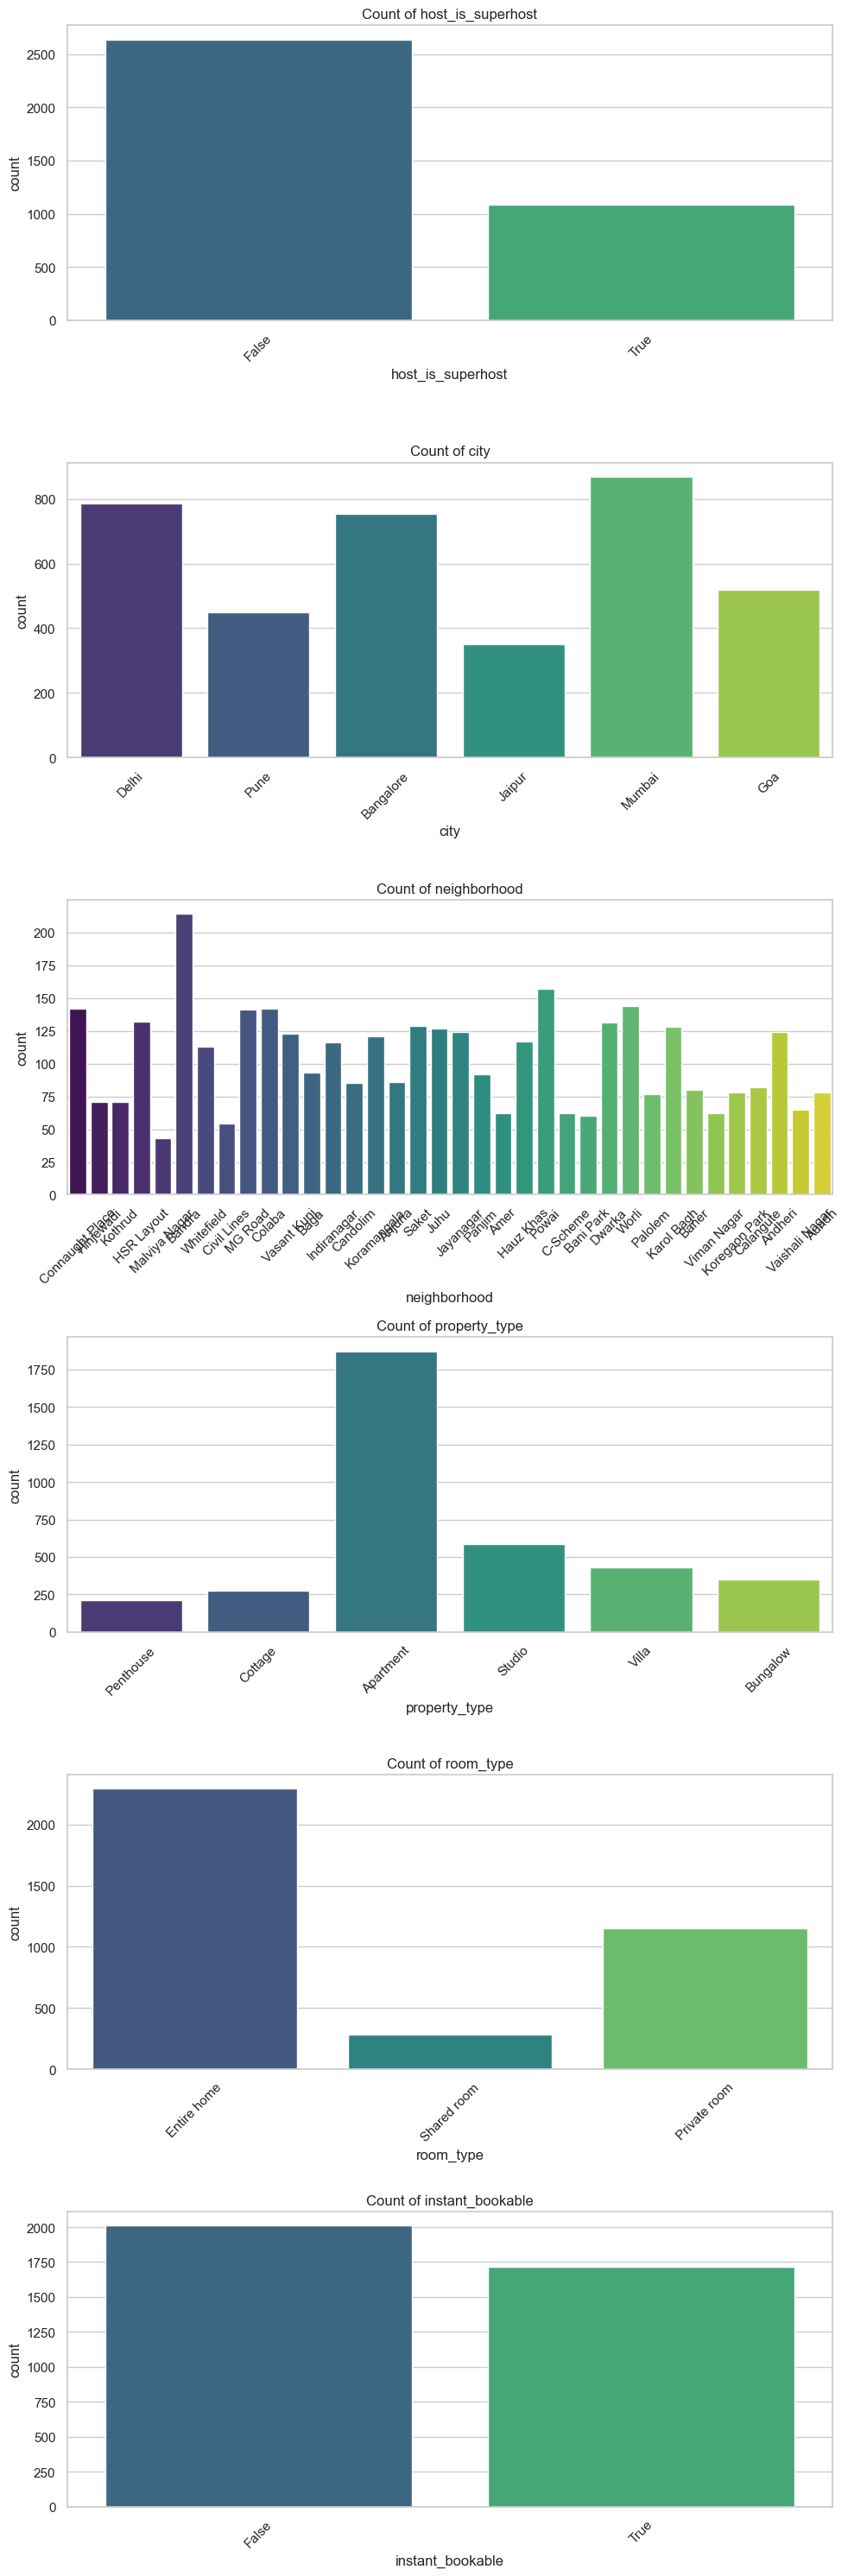

In [14]:
# 1. Define the categorical columns to analyze
cat_cols_to_analyze = ['host_is_superhost', 'city', 'neighborhood', 'property_type', 'room_type', 'instant_bookable']

# 2. Setup the Plotting Grid
# We calculate the number of rows/cols needed to keep the layout clean
n = len(cat_cols_to_analyze)
fig, axes = plt.subplots(n, 1, figsize=(10, 5 * n)) 

# If only one column, axes isn't a list, so we wrap it
if n == 1: axes = [axes]

# 3. Iterate and Plot
for i, col in enumerate(cat_cols_to_analyze):
    # Print numerical summary first
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Count': counts, 'Percentage': percentages.map('{:.2f}%'.format)})
    print(f"\n--- {col} Summary ---\n", summary)
    
    # Plot using hue=col and legend=False to fix the warning
    sns.countplot(data=df, x=col, palette='viridis', hue=col, legend=False, ax=axes[i])
    axes[i].set_title(f'Count of {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
# Save the final combined plot
plt.savefig('categorical_counts_summary.png', dpi=300, bbox_inches='tight')
plt.show()

### 9.2 Looking Again at the Continuous variable

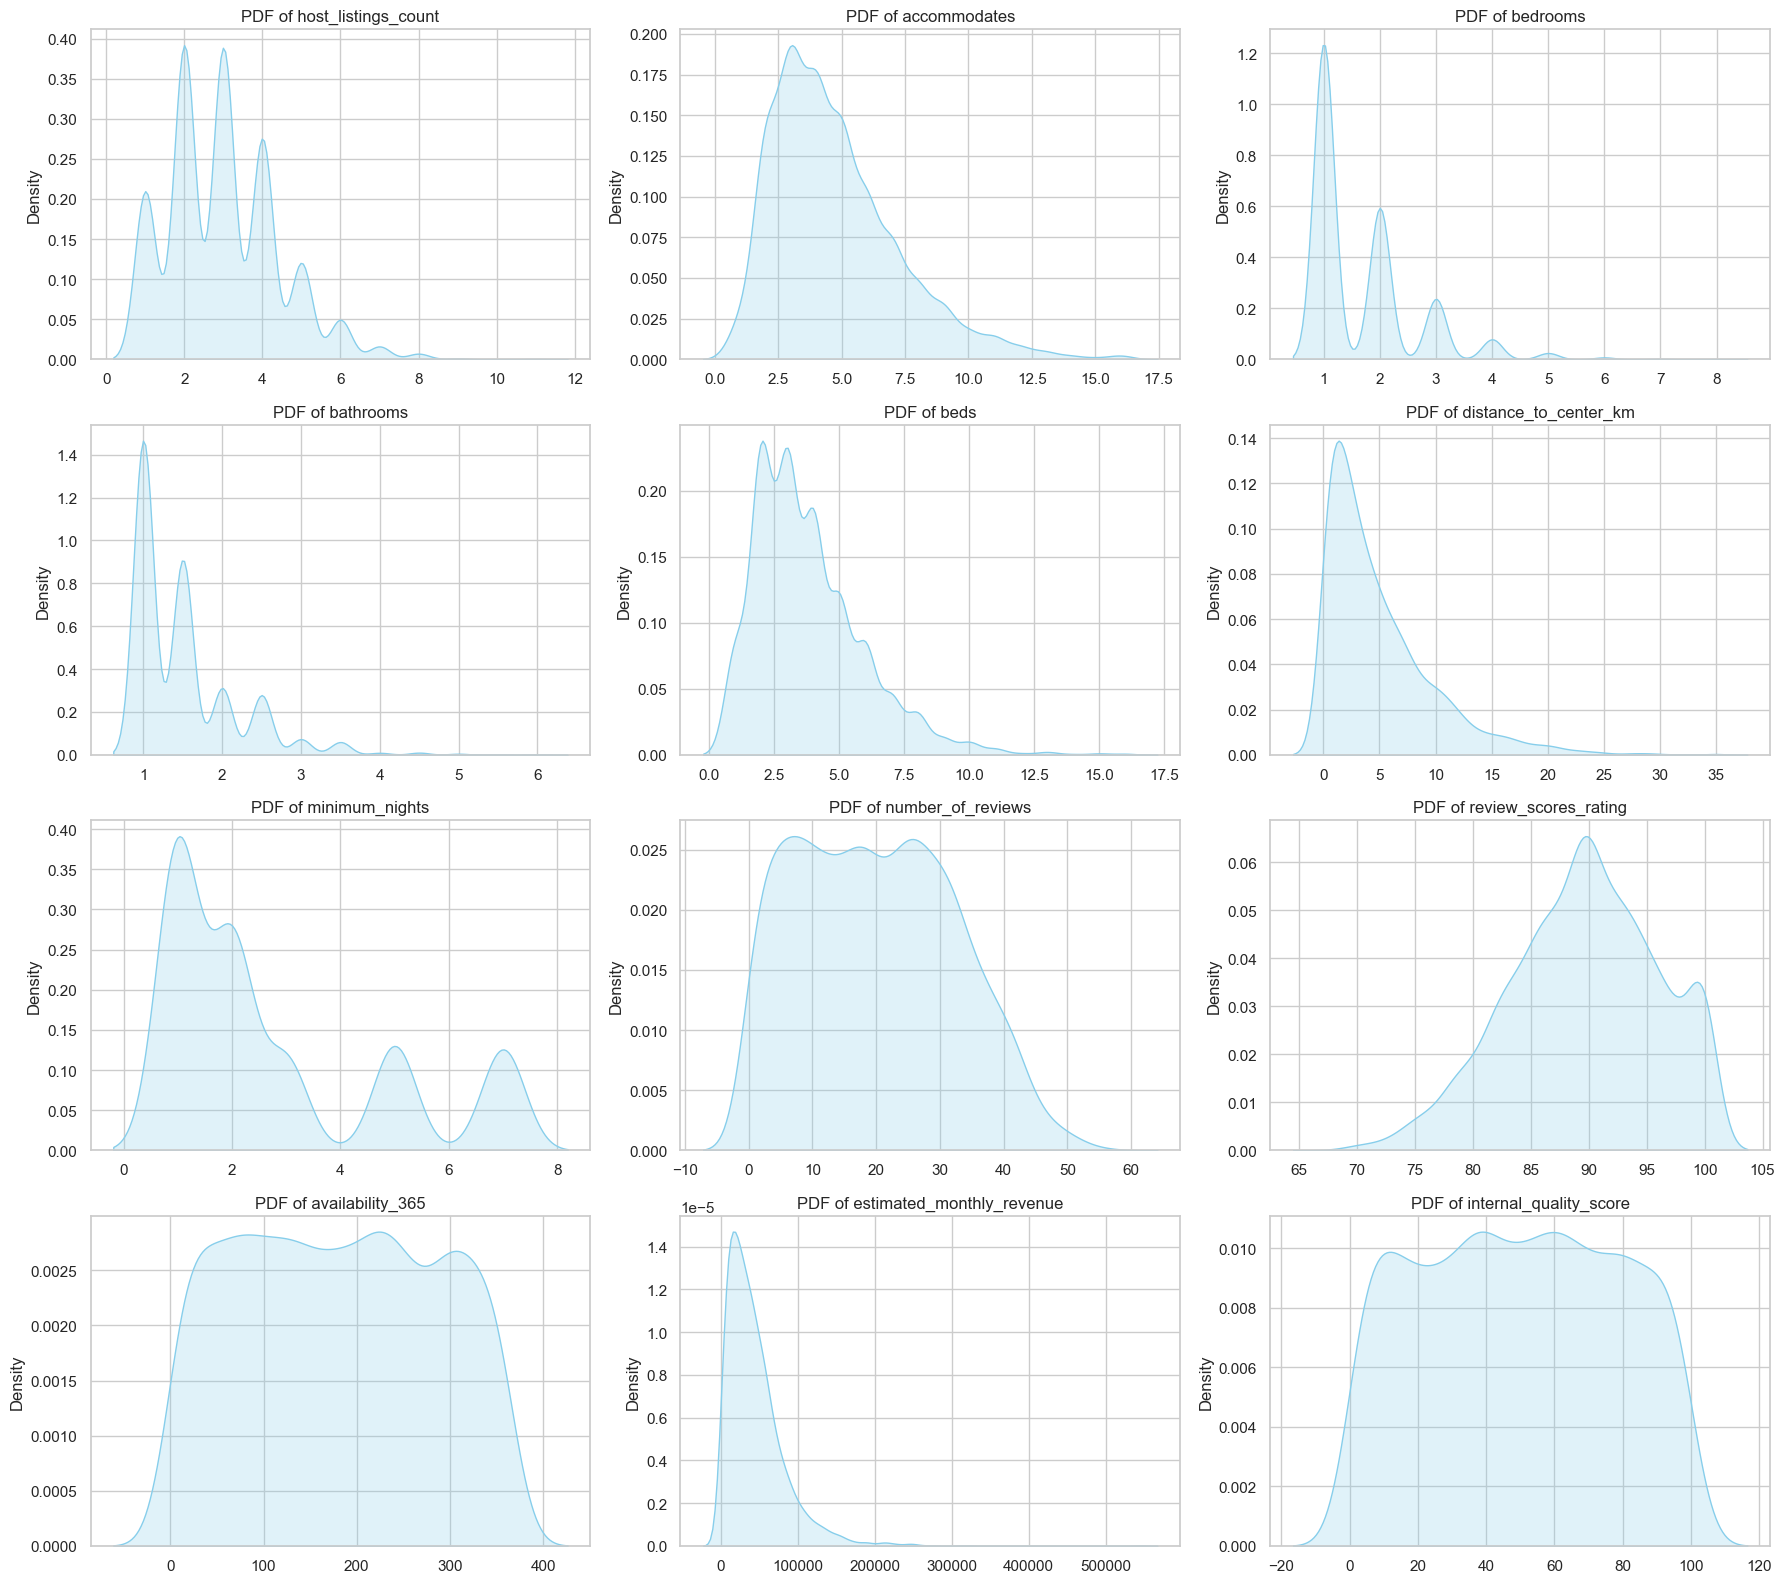

In [16]:
# Identify continuous columns (excluding IDs and categorical text)
continuous_cols = [
    'host_listings_count', 'accommodates', 'bedrooms', 'bathrooms', 'beds', 
    'distance_to_center_km', 'minimum_nights', 'number_of_reviews', 
    'review_scores_rating', 'availability_365', 'estimated_monthly_revenue', 
    'internal_quality_score'
]

# Set up the figure for subplots
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()  # Flatten the grid to make it easier to iterate

# Create a kdeplot for each column
for i, col in enumerate(continuous_cols):
    sns.kdeplot(data=df, x=col, ax=axes[i], fill=True, color='skyblue')
    axes[i].set_title(f'PDF of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

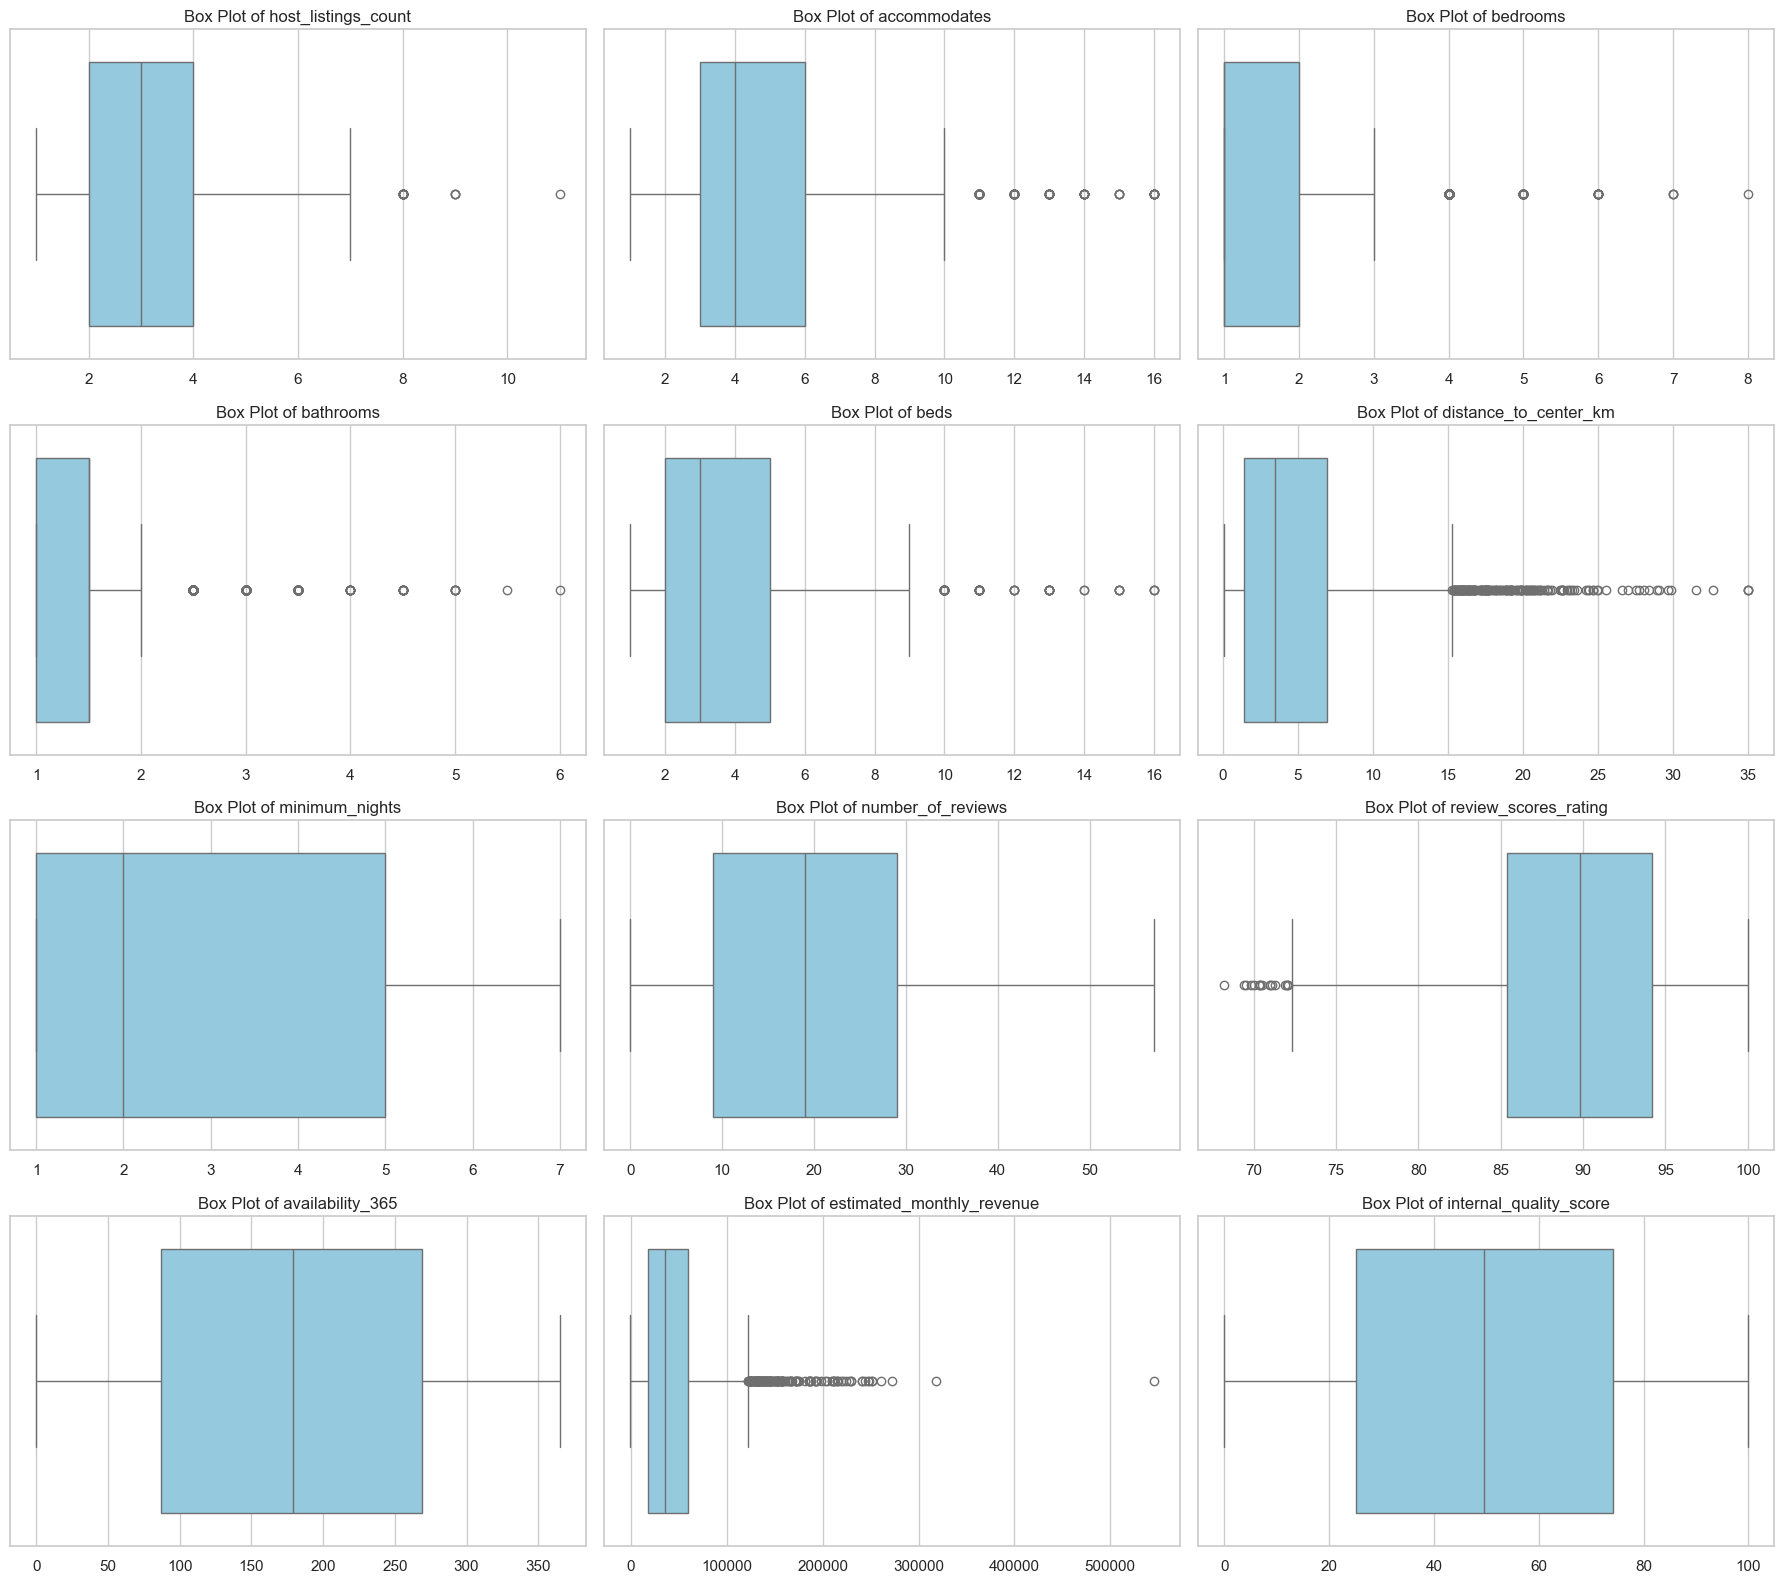

In [22]:
# Identify continuous columns (excluding IDs and categorical text)
continuous_cols = [
    'host_listings_count', 'accommodates', 'bedrooms', 'bathrooms', 'beds', 
    'distance_to_center_km', 'minimum_nights', 'number_of_reviews', 
    'review_scores_rating', 'availability_365', 'estimated_monthly_revenue', 
    'internal_quality_score'
]

# Set up the figure for subplots
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()  # Flatten the grid to make it easier to iterate

# Create a boxplot for each column
for i, col in enumerate(continuous_cols):
    # Swapped kdeplot for boxplot
    sns.boxplot(data=df, x=col, ax=axes[i], color='skyblue') 
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

## 10. Clean the Price Column

`price` is stored as a string with a `₹` symbol and thousands separators (e.g. `₹4,647`). Strip those characters and convert to a numeric `float` so it can be used in plots and analysis.

In [17]:
# Clean price column: remove '₹' and ',' then convert to float
df['price'] = df['price'].replace({'\₹': '', ',': ''}, regex=True).astype(float)

## 11. Target Variable Analysis

`price` is stored as a string with a `₹` symbol and thousands separators (e.g. `₹4,647`). Strip those characters and convert to a numeric `float` so it can be used in plots and analysis.

### 11.1 Continuous variables vs Price

Scatter plots of each continuous variable against the cleaned `price`.

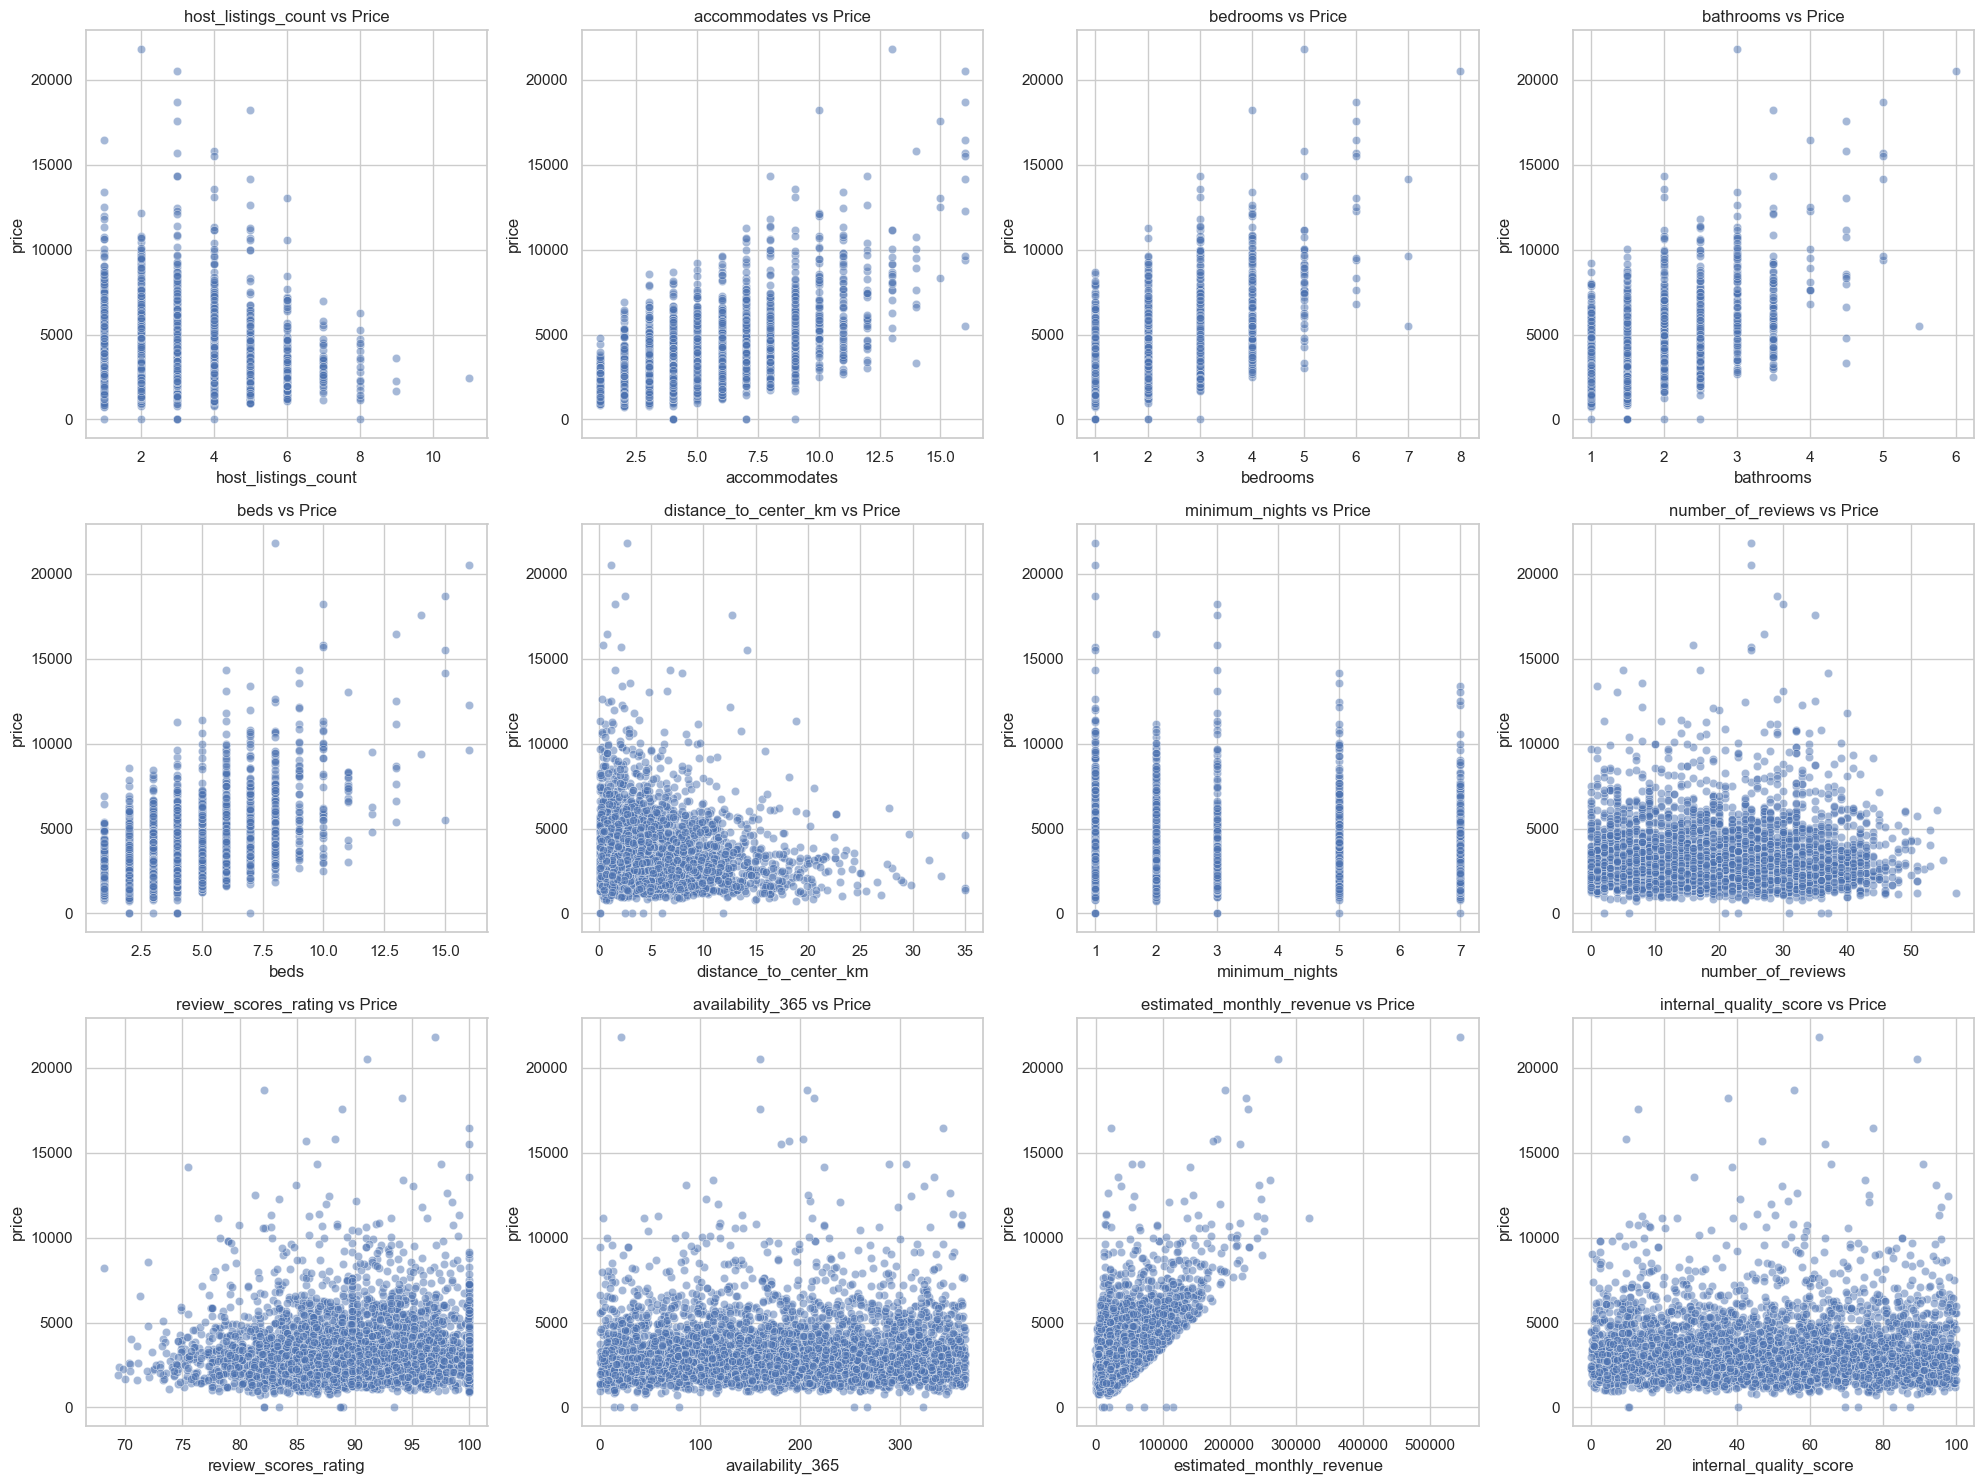

In [19]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

continuous_vars = [
    'host_listings_count', 'accommodates', 'bedrooms', 'bathrooms', 'beds', 
    'distance_to_center_km', 'minimum_nights', 'number_of_reviews', 
    'review_scores_rating', 'availability_365', 'estimated_monthly_revenue', 
    'internal_quality_score'
]

# Set up a grid layout (e.g., 4 columns)
n_cols = 4
n_rows = math.ceil(len(continuous_vars) / n_cols)

# Create a proportional figure size based on rows and columns
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(continuous_vars):
    sns.scatterplot(data=df, x=col, y='price', ax=axes[i], alpha=0.5)
    axes[i].set_title(f'{col} vs Price')

# (Optional) Hide any extra empty subplots if your list length isn't perfectly divisible by n_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# Save as PNG with higher DPI, OR save as SVG for infinite scaling
plt.savefig('my_scatter_plot.png', dpi=400, bbox_inches='tight')
# plt.savefig('my_scatter_plot.svg', format='svg', bbox_inches='tight') # Uncomment this for a vector graphic

plt.show()

### 11.2 Catagorical variables vs Price

Scatter plots of each continuous variable against the cleaned `price`.

In [20]:


# List of categorical features to analyze against 'price'
categorical_vars =  ['host_is_superhost', 'city', 'neighborhood', 'property_type', 'room_type', 'instant_bookable']

# Analyze Price by Categorical Variables
for col in categorical_vars:
    # Group by the category and calculate mean and median for the price column
    summary = df.groupby(col)['price'].agg(['mean', 'median', 'count']).sort_values(by='median', ascending=False)
    
    print(f"\n--- Price Analysis by {col} ---")
    print(summary)
    print("-" * 40)



--- Price Analysis by host_is_superhost ---
                          mean  median  count
host_is_superhost                            
True               3591.277319  3105.0   1089
False              3357.813804  2873.0   2637
----------------------------------------

--- Price Analysis by city ---
                  mean  median  count
city                                 
Goa        4383.017375  3804.5    518
Mumbai     3860.574223  3312.0    869
Delhi      3240.136306  2824.0    785
Bangalore  3208.076923  2742.5    754
Jaipur     2832.467236  2444.0    351
Pune       2636.126949  2191.0    449
----------------------------------------

--- Price Analysis by neighborhood ---
                        mean  median  count
neighborhood                               
Baga             4737.043011  4355.0     93
Candolim         4318.705882  4030.0     85
Palolem          4388.038961  3870.0     77
Calangute        4421.439024  3663.5     82
Worli            4117.319444  3531.0    144
Panji

C:\Users\saifa\AppData\Local\Temp\ipykernel_17196\1960410935.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='price', ax=axes[i], palette='viridis')
C:\Users\saifa\AppData\Local\Temp\ipykernel_17196\1960410935.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='price', ax=axes[i], palette='viridis')
C:\Users\saifa\AppData\Local\Temp\ipykernel_17196\1960410935.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='price', ax=axes[i], palette='viridis')
C:\Users\saifa\AppData\Local\Te

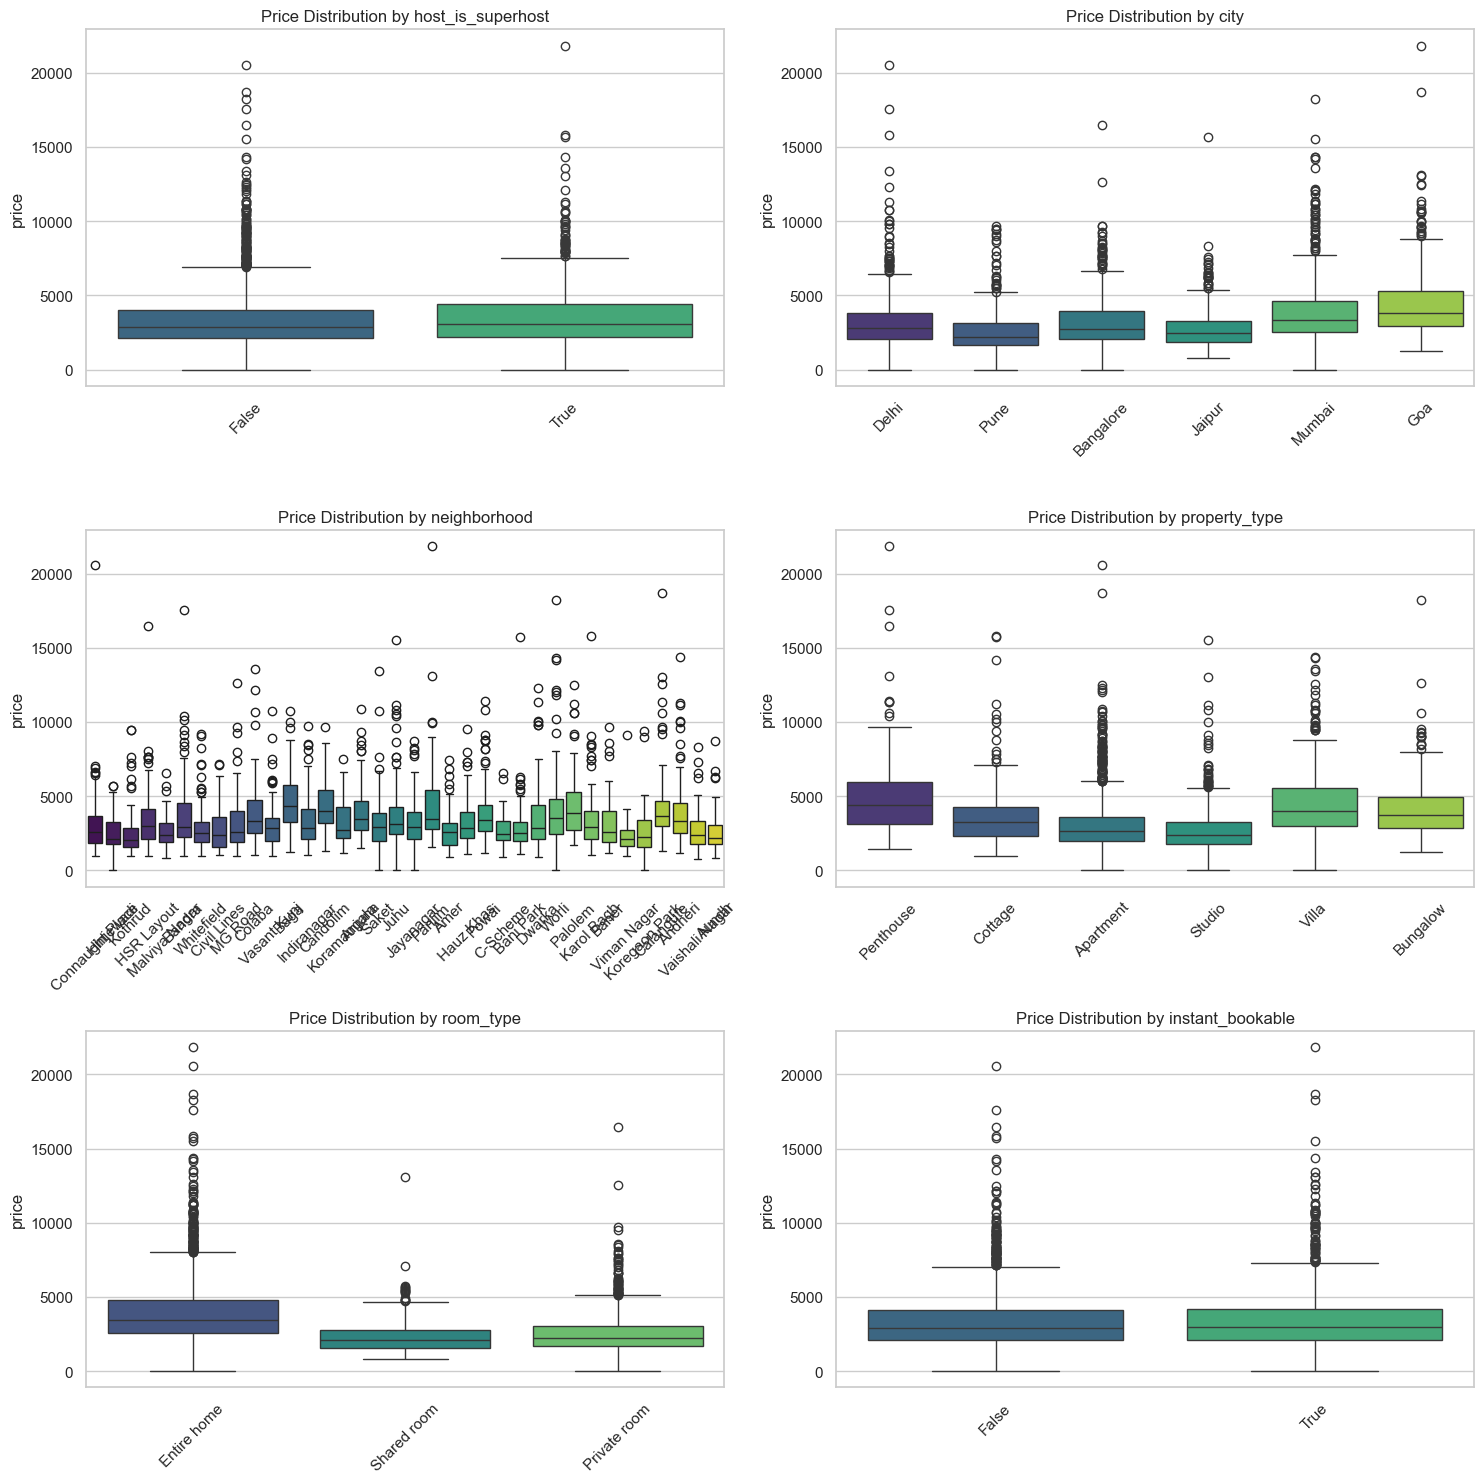

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the categorical variables
categorical_vars = ['host_is_superhost', 'city', 'neighborhood', 'property_type', 'room_type', 'instant_bookable']

# Set up the plot grid (we'll make a grid with 2 columns)
# Adjust the number of rows based on the number of variables
n_cols = 2
n_rows = (len(categorical_vars) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # Flatten to make it easier to iterate

# Iterate through variables and create a boxplot for each
for i, col in enumerate(categorical_vars):
    sns.boxplot(data=df, x=col, y='price', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Price Distribution by {col}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

# Remove empty subplots if the number of variables is odd
if len(categorical_vars) % 2 != 0:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig('categorical_price_analysis.png', dpi=300)
plt.show()

## ✅ DataFrame Ready

At this point the data types are corrected, invalid records are removed, the categorical variables are standardised, and all missing values are handled. The DataFrame `df` is clean and ready for the next steps. Continue your work in the cell below.

In [23]:
# Check structural changes and data types
print("--- DataFrame Info ---")
df.info()

# Check for any newly introduced nulls during cleaning
print("\n--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Visually verify the cleaned columns (city, host_is_superhost, etc.)
df.head()

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 3726 entries, 0 to 4034
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   listing_id                 3726 non-null   object        
 1   host_id                    3726 non-null   int64         
 2   host_since                 3726 non-null   datetime64[ns]
 3   host_is_superhost          3726 non-null   bool          
 4   host_listings_count        3726 non-null   int64         
 5   city                       3726 non-null   object        
 6   neighborhood               3726 non-null   object        
 7   property_type              3726 non-null   object        
 8   room_type                  3726 non-null   object        
 9   accommodates               3726 non-null   int64         
 10  bedrooms                   3726 non-null   float64       
 11  bathrooms                  3726 non-null   float64 

,listing_id,host_id,host_since,host_is_superhost,host_listings_count,city,neighborhood,property_type,room_type,accommodates,...,amenities,distance_to_center_km,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable,availability_365,estimated_monthly_revenue,internal_quality_score,price
0,WS100859,1741,2016-06-26,True,1,Delhi,Connaught Place,Penthouse,Entire home,6,...,"{Wifi,AC,Pool,Washing Machine,TV,Heater,Pet Fr...",0.19,1,23,82.5,False,197,57789.0,59.3,4647.0
1,WS103542,2132,2024-03-27,True,4,Pune,Hinjewadi,Cottage,Shared room,7,...,"{Wifi,AC,Kitchen,Parking,TV}",3.52,1,5,90.0,True,141,47279.0,14.9,2799.0
2,WS103703,4530,2015-07-23,False,3,Pune,Kothrud,Apartment,Private room,5,...,"{Wifi,AC,Washing Machine,TV,Heater}",10.40,7,13,91.5,True,48,20813.0,16.2,1138.0
3,WS101270,3058,2018-06-07,True,2,Bangalore,HSR Layout,Studio,Shared room,2,...,"{Wifi,AC,Kitchen,TV,Heater,Workspace}",4.86,3,16,83.0,True,150,14777.0,93.5,947.0
4,WS103190,7081,2020-02-26,False,3,Jaipur,Malviya Nagar,Villa,Entire home,2,...,"{Wifi,AC,Kitchen,Parking,Pool,TV}",2.99,7,16,74.2,True,111,62754.0,31.3,3038.0


## 12 Target Variable Analysis

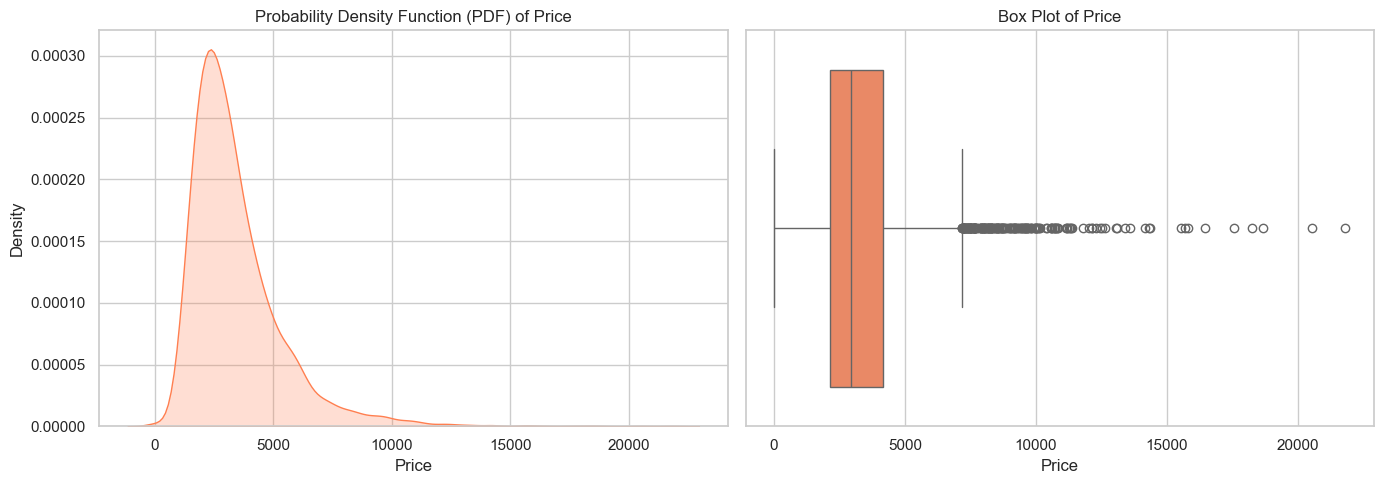

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot the PDF (Probability Density Function) using KDE
sns.kdeplot(data=df, x='price', fill=True, color='coral', ax=axes[0])
axes[0].set_title('Probability Density Function (PDF) of Price')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Density')

# 2. Plot the Box Plot
sns.boxplot(data=df, x='price', color='coral', ax=axes[1])
axes[1].set_title('Box Plot of Price')
axes[1].set_xlabel('Price')

plt.tight_layout()
plt.show()

## 13 Feature Engineering 

In [25]:
# ============================================================
# FEATURE ENGINEERING
# Works on a copy so the cleaned `df` stays intact.
# ============================================================
import numpy as np
import pandas as pd

fe = df.copy()
REFERENCE_DATE = fe['host_since'].max()   # reproducible anchor, not "today"

# ===== 1 · HOST =====
fe['host_tenure_days']         = (REFERENCE_DATE - fe['host_since']).dt.days
fe['host_tenure_years']        = fe['host_tenure_days'] / 365.25
fe['listings_per_tenure_year'] = fe['host_listings_count'] / (fe['host_tenure_years'] + 1)
fe['is_superhost']             = fe['host_is_superhost'].astype(int)

# ===== 2 · GEOGRAPHY =====
print('Unique cities:', fe['city'].nunique(), '| neighborhoods:', fe['neighborhood'].nunique())

# Route 1: describe each neighborhood by its OTHER attributes (no price -> no leakage)
nbhd_agg = fe.groupby('neighborhood').agg(
    nbhd_avg_distance     = ('distance_to_center_km', 'mean'),
    nbhd_avg_accommodates = ('accommodates', 'mean'),
    nbhd_avg_rating       = ('review_scores_rating', 'mean'),
    nbhd_superhost_rate   = ('host_is_superhost', 'mean'),
    nbhd_entire_home_rate = ('room_type', lambda s: (s == 'Entire home').mean()),
)
fe = fe.merge(nbhd_agg, on='neighborhood', how='left')

# Distance features
fe['is_central_1km']       = (fe['distance_to_center_km'] < 1).astype(int)
fe['is_central_2km']       = (fe['distance_to_center_km'] < 2).astype(int)
fe['distance_vs_city_avg'] = fe['distance_to_center_km'] - fe.groupby('city')['distance_to_center_km'].transform('mean')

# Log-transformed distance to handle the diminishing returns effect
fe['log_distance_to_center_km'] = np.log1p(fe['distance_to_center_km'])

# ===== 3 · PROPERTY =====
fe['bed_bath_ratio']     = fe['bedrooms']     / fe['bathrooms'].replace(0, np.nan)
fe['bath_per_guest']     = fe['bathrooms']    / fe['accommodates'].replace(0, np.nan)
fe['beds_per_guest']     = fe['beds']         / fe['accommodates'].replace(0, np.nan)
fe['guests_per_bedroom'] = fe['accommodates'] / fe['bedrooms'].replace(0, np.nan)

ratio_cols = ['bed_bath_ratio', 'bath_per_guest', 'beds_per_guest', 'guests_per_bedroom']
fe[ratio_cols] = fe[ratio_cols].fillna(fe[ratio_cols].median())

fe['is_large_property'] = (fe['accommodates'] >= 4).astype(int)

# Inspect the property/room relationship, then encode the combo
print(pd.crosstab(fe['property_type'], fe['room_type']))
fe['prop_room_combo'] = fe['property_type'] + ' | ' + fe['room_type']
fe['prop_room_freq']  = fe['prop_room_combo'].map(fe['prop_room_combo'].value_counts(normalize=True))

# ===== 4 · RATINGS =====
fe['has_reviews']             = (fe['number_of_reviews'] > 0).astype(int)
fe['log_reviews']             = np.log1p(fe['number_of_reviews'])   # reviews are heavily skewed
fe['reviews_per_tenure_year'] = fe['number_of_reviews'] / (fe['host_tenure_years'] + 1)

# ===== 5 · PERKS (amenities + booking) =====
fe['amenities_list'] = (
    fe['amenities'].str.strip('{}').str.split(',')
      .apply(lambda lst: [a.strip() for a in lst if a.strip()])
)
fe['amenity_count'] = fe['amenities_list'].apply(len)

key_amenities = ['Wifi', 'AC', 'Pool', 'Kitchen', 'Parking', 'TV',
                 'Heater', 'Washing Machine', 'Workspace', 'Pet Friendly']
for a in key_amenities:
    fe['has_' + a.lower().replace(' ', '_')] = fe['amenities_list'].apply(lambda lst, a=a: int(a in lst))

fe['is_instant_bookable'] = fe['instant_bookable'].astype(int)
fe['availability_ratio']  = fe['availability_365'] / 365

# ===== 6 · REVENUE (EDA only — NOT a model feature) =====
bins   = [0, 1e5, 2e5, 3e5, 4e5, 5e5, 6e5, 7e5, 8e5, 9e5, 10e5]
labels = ['0-1L','1-2L','2-3L','3-4L','4-5L','5-6L','6-7L','7-8L','8-9L','9-10L']
fe['revenue_band'] = pd.cut(fe['estimated_monthly_revenue'], bins=bins, labels=labels, include_lowest=True)

# ===== 7 · TARGET VARIABLE TRANSFORM =====
# Log transform price to normalize the heavily right-skewed distribution
if 'price' in fe.columns:
    fe['log_price'] = np.log1p(fe['price'])

# ===== 8 · ENCODE LOW-CARDINALITY CATEGORICALS =====
fe = pd.get_dummies(fe, columns=['city', 'room_type', 'property_type'],
                    prefix=['city', 'room', 'prop'], drop_first=False)

# ===== 9 · BUILD THE FINAL MODELING FRAME =====
drop_cols = [
    'listing_id', 'host_id', 'host_since',          # identifiers / raw date
    'host_is_superhost', 'instant_bookable',        # replaced by int flags
    'neighborhood', 'amenities', 'amenities_list',  # replaced by aggregates / parsed
    'prop_room_combo',                              # helper text
    'estimated_monthly_revenue', 'revenue_band',    # leaky (downstream of price)
]
model_df = fe.drop(columns=[c for c in drop_cols if c in fe.columns])

# Make boolean dummy columns plain 0/1 ints (safer across model types)
bool_cols = model_df.select_dtypes(include='bool').columns
model_df[bool_cols] = model_df[bool_cols].astype(int)

print('Final modeling frame shape:', model_df.shape)
print('Remaining nulls:', model_df.isnull().sum().sum())
model_df.head()

Unique cities: 6 | neighborhoods: 36
room_type      Entire home  Private room  Shared room
property_type                                        
Apartment             1149           585          137
Bungalow               207           112           31
Cottage                180            78           17
Penthouse              133            60           19
Studio                 360           181           45
Villa                  264           134           34
Final modeling frame shape: (3726, 63)
Remaining nulls: 0


,host_listings_count,accommodates,bedrooms,bathrooms,beds,distance_to_center_km,minimum_nights,number_of_reviews,review_scores_rating,availability_365,...,city_Pune,room_Entire home,room_Private room,room_Shared room,prop_Apartment,prop_Bungalow,prop_Cottage,prop_Penthouse,prop_Studio,prop_Villa
0,1,6,2.0,1.5,4,0.19,1,23,82.5,197,...,0,1,0,0,0,0,0,1,0,0
1,4,7,3.0,2.5,6,3.52,1,5,90.0,141,...,1,0,0,1,0,0,1,0,0,0
2,3,5,1.0,1.5,3,10.40,7,13,91.5,48,...,1,0,1,0,1,0,0,0,0,0
3,2,2,1.0,1.0,2,4.86,3,16,83.0,150,...,0,0,0,1,0,0,0,0,1,0
4,3,2,1.0,1.0,2,2.99,7,16,74.2,111,...,0,1,0,0,0,0,0,0,0,1


## 14 Feature Corelation


In [31]:
import pandas as pd
import numpy as np

# 1. Combine X_train and y_train temporarily to check target correlations
# (CRITICAL: We only use train data here to prevent data leakage!)
train_data = X_train.copy()
train_data['log_price'] = y_train

# 2. Calculate the Pearson correlation matrix
corr_matrix = train_data.corr()

# 3. WHAT DRIVES PRICE? (Correlation with Target)
# Sort by absolute value to see the strongest impacts (both positive and negative)
target_corr = corr_matrix['log_price'].drop('log_price').sort_values(key=abs, ascending=False)

print("--- Top 15 Features Correlated with Price ---")
print(target_corr.head(15))

print("\n--- Bottom 5 Features (Weakest Correlation) ---")
print(target_corr.tail(5))

# 4. MULTICOLLINEARITY CHECK
# Find features that are highly correlated with EACH OTHER
threshold = 0.75  # You can adjust this (0.75 to 0.85 is a standard cutoff)
high_corr_pairs = []

# Iterate through the upper triangle of the matrix to avoid duplicates
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        
        # Skip the target variable; we only care about feature-to-feature here
        if col1 == 'log_price' or col2 == 'log_price':
            continue
            
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) >= threshold:
            high_corr_pairs.append((col1, col2, corr_val))

# Sort the highly correlated pairs by absolute correlation
high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"\n--- Highly Correlated Feature Pairs (Threshold > {threshold}) ---")
if len(high_corr_pairs) > 0:
    for pair in high_corr_pairs:
        print(f"{pair[0]} & {pair[1]}: {pair[2]:.2f}")
else:
    print("No feature pairs exceed the correlation threshold.")

--- Top 15 Features Correlated with Price ---
accommodates         0.475678
bedrooms             0.474228
beds                 0.452980
bathrooms            0.427239
room_Entire home     0.353402
is_large_property    0.302197
room_Private room   -0.277665
has_pool             0.276155
bath_per_guest      -0.231934
bed_bath_ratio       0.207463
prop_Villa           0.196441
city_Goa             0.185379
prop_Apartment      -0.182553
city_Pune           -0.172495
room_Shared room    -0.166175
Name: log_price, dtype: float64

--- Bottom 5 Features (Weakest Correlation) ---
reviews_per_tenure_year   -0.001153
host_tenure_days          -0.000931
host_tenure_years         -0.000931
guests_per_bedroom        -0.000483
has_washing_machine        0.000459
Name: log_price, dtype: float64

--- Highly Correlated Feature Pairs (Threshold > 0.75) ---
host_tenure_days & host_tenure_years: 1.00
availability_365 & availability_ratio: 1.00
distance_to_center_km & distance_vs_city_avg: 1.00
accommodates 

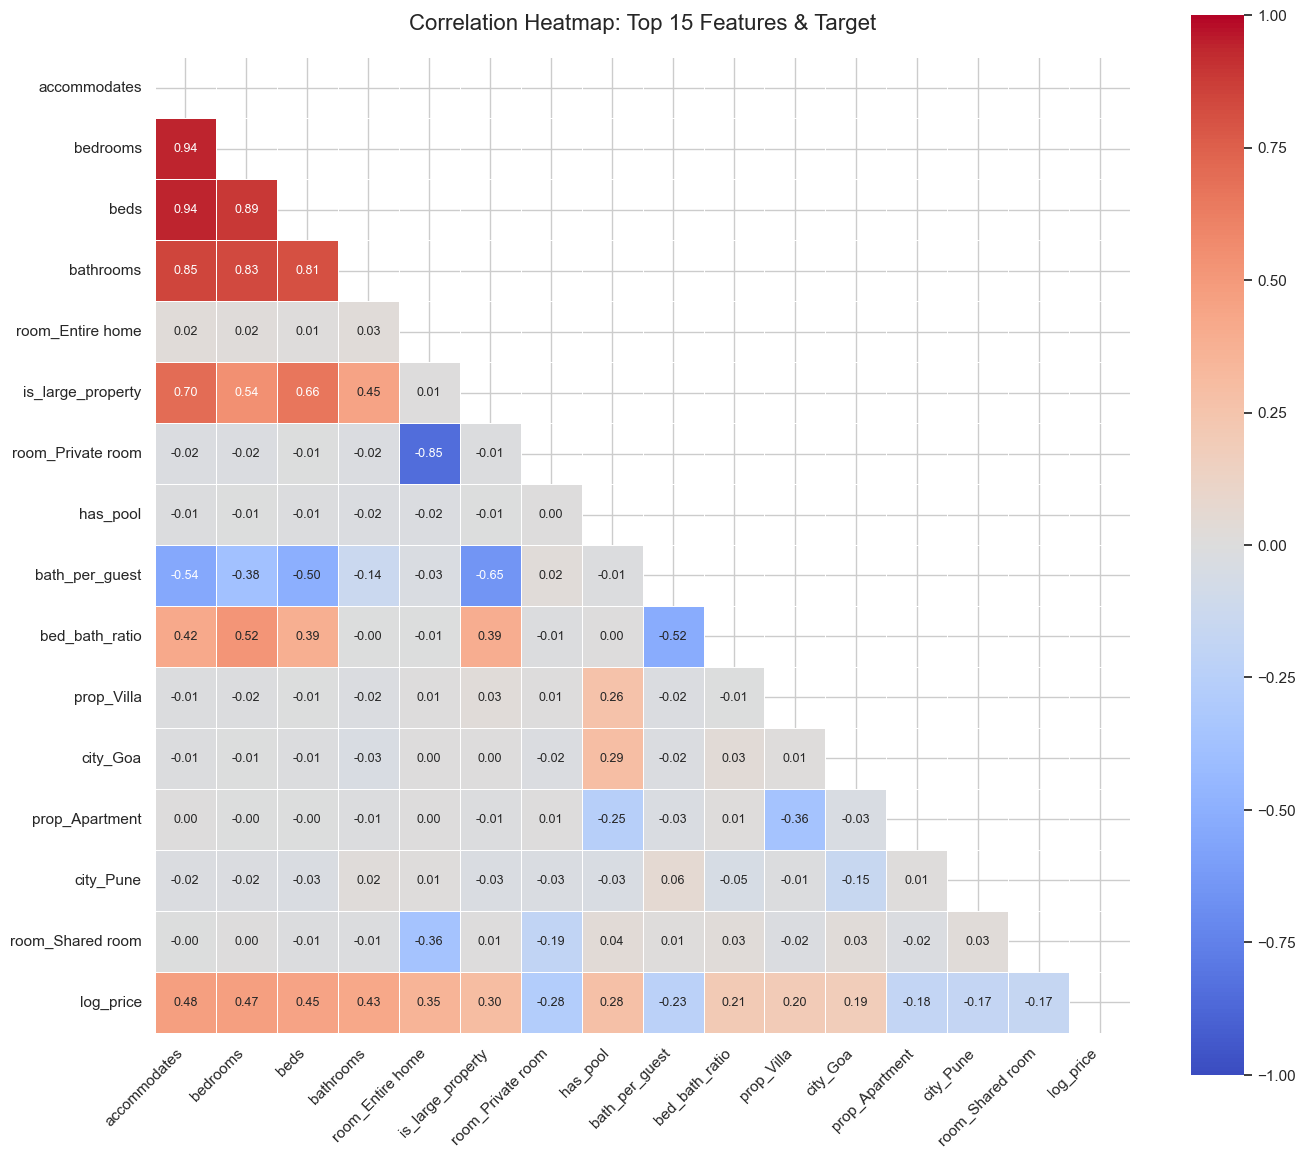

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Grab the top 15 feature names from your previous analysis and add the target
top_features = target_corr.head(15).index.tolist()
top_features.append('log_price') 

# 2. Create a smaller correlation matrix using ONLY these top features
top_corr_matrix = train_data[top_features].corr()

# 3. Set up the figure size
plt.figure(figsize=(14, 12))

# 4. Create a mask to hide the upper triangle (removes duplicate information)
mask = np.triu(np.ones_like(top_corr_matrix, dtype=bool))

# 5. Plot the heatmap
sns.heatmap(
    top_corr_matrix, 
    mask=mask, 
    cmap='coolwarm',       # Blue for negative, Red for positive correlation
    vmax=1.0, 
    vmin=-1.0, 
    center=0,
    square=True, 
    linewidths=.5, 
    annot=True,            # Prints the actual correlation numbers inside the boxes
    fmt=".2f",             # Rounds the numbers to 2 decimal places
    annot_kws={"size": 9}  # Adjusts font size inside the boxes
)

plt.title('Correlation Heatmap: Top 15 Features & Target', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [33]:
# 1. Define the exact features to drop based on your correlation findings
features_to_drop = [
    # Bottom 5 weakest correlations with target
    'reviews_per_tenure_year',
    'host_tenure_days',        
    'host_tenure_years',       
    'guests_per_bedroom',
    'has_washing_machine',
    
    # Redundant pairs from the multicollinearity check (> 0.75)
    'availability_ratio',      # Keeping availability_365
    'number_of_reviews',       # Keeping log_reviews
    'distance_to_center_km',   # Keeping log_distance_to_center_km
    'distance_vs_city_avg',    # Keeping log_distance_to_center_km
    'is_central_2km',          # Highly negatively correlated with log_distance
    'beds',                    # Correlated with accommodates
    'bedrooms',                # Correlated with accommodates
    'room_Private room',       # Correlated with room_Entire home
    'prop_room_freq'           # Correlated with prop_Apartment
]

# 2. Drop these features from the main modeling dataframe
model_df = model_df.drop(columns=features_to_drop, errors='ignore')

print(f"Features dropped successfully. New model_df shape: {model_df.shape}")

Features dropped successfully. New model_df shape: (3726, 49)


## 15 5 fold split and  Running the Model

In [37]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import scipy.stats as stats
import numpy as np

# 1. Define target (y) and features (X) from your cleaned model_df
y = model_df['log_price']
X = model_df.drop(columns=['log_price', 'price'], errors='ignore')

# 2. Set up the 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store the TESTING metrics
r2_test_scores = []
adj_r2_test_scores = []
f_stat_scores = []
p_value_scores = []
rmse_test_scores = []
mae_test_scores = []

# Lists to store the TRAINING metrics
r2_train_scores = []
rmse_train_scores = []
mae_train_scores = []

# Initialize the model
lr_model = LinearRegression()

print("--- Running 5-Fold Cross Validation ---\n")

# 3. Loop through each of the 5 folds
fold = 1
for train_index, test_index in kf.split(X):
    
    # Split the data into training and testing for this specific fold
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
    
    # Train the model
    lr_model.fit(X_train_fold, y_train_fold)
    
    # --- CALCULATE TRAINING METRICS ---
    y_train_pred_log = lr_model.predict(X_train_fold)
    r2_train = r2_score(y_train_fold, y_train_pred_log)
    r2_train_scores.append(r2_train)
    
    y_train_actual = np.expm1(y_train_fold)
    y_train_pred_actual = np.expm1(y_train_pred_log)
    
    rmse_train = np.sqrt(mean_squared_error(y_train_actual, y_train_pred_actual))
    mae_train = mean_absolute_error(y_train_actual, y_train_pred_actual)
    
    rmse_train_scores.append(rmse_train)
    mae_train_scores.append(mae_train)

    # --- CALCULATE TESTING METRICS ---
    y_test_pred_log = lr_model.predict(X_test_fold)
    r2_test = r2_score(y_test_fold, y_test_pred_log)
    r2_test_scores.append(r2_test)
    
    # Statistical Inference Metrics for Test Fold
    n_fold = X_test_fold.shape[0]
    p_fold = X_test_fold.shape[1]
    
    adj_r2 = 1 - (1 - r2_test) * (n_fold - 1) / (n_fold - p_fold - 1)
    adj_r2_test_scores.append(adj_r2)
    
    f_stat = (r2_test / p_fold) / ((1 - r2_test) / (n_fold - p_fold - 1))
    f_stat_scores.append(f_stat)
    
    p_value = stats.f.sf(f_stat, p_fold, n_fold - p_fold - 1)
    p_value_scores.append(p_value)
    
    y_test_actual = np.expm1(y_test_fold)
    y_test_pred_actual = np.expm1(y_test_pred_log)
    
    rmse_test = np.sqrt(mean_squared_error(y_test_actual, y_test_pred_actual))
    mae_test = mean_absolute_error(y_test_actual, y_test_pred_actual)
    
    rmse_test_scores.append(rmse_test)
    mae_test_scores.append(mae_test)
    
    print(f"Fold {fold} | Train R2: {r2_train:.4f} vs Test R2: {r2_test:.4f} | Adj R2: {adj_r2:.4f}")
    fold += 1

# 4. Print the final averaged results
print("\n--- 5-Fold Cross-Validation Average Performance ---")

print("\n[Training Averages]")
print(f"Average R-squared: {np.mean(r2_train_scores):.4f}")
print(f"Average RMSE:      {np.mean(rmse_train_scores):.2f}")
print(f"Average MAE:       {np.mean(mae_train_scores):.2f}")

print("\n[Testing Averages & Statistics]")
print(f"Average R-squared:      {np.mean(r2_test_scores):.4f}")
print(f"Average Adj R-squared:  {np.mean(adj_r2_test_scores):.4f}")
print(f"Average F-Statistic:    {np.mean(f_stat_scores):.2f}")
print(f"Average P-value:        {np.mean(p_value_scores):.2e}")
print(f"Average RMSE:           {np.mean(rmse_test_scores):.2f}")
print(f"Average MAE:            {np.mean(mae_test_scores):.2f}")

--- Running 5-Fold Cross Validation ---

Fold 1 | Train R2: 0.5738 vs Test R2: 0.6305 | Adj R2: 0.6056
Fold 2 | Train R2: 0.5779 vs Test R2: 0.6066 | Adj R2: 0.5801
Fold 3 | Train R2: 0.5742 vs Test R2: 0.6218 | Adj R2: 0.5963
Fold 4 | Train R2: 0.5680 vs Test R2: 0.6511 | Adj R2: 0.6275
Fold 5 | Train R2: 0.6389 vs Test R2: 0.4311 | Adj R2: 0.3928

--- 5-Fold Cross-Validation Average Performance ---

[Training Averages]
Average R-squared: 0.5866
Average RMSE:      753.98
Average MAE:       510.36

[Testing Averages & Statistics]
Average R-squared:      0.5882
Average Adj R-squared:  0.5605
Average F-Statistic:    22.30
Average P-value:        3.42e-59
Average RMSE:           765.79
Average MAE:            518.79


In [40]:
from sklearn.model_selection import KFold

# --- FIX: YOU MUST DEFINE worst_idx FIRST ---

# Option A: If you already know the exact row index of the outlier, type it directly:
worst_idx = 1054  # Replace 1054 with your actual outlier's index number

# Option B: If you want Python to find the index with the absolute largest error 
# from your previous residual calculations in Cell 29:
# worst_idx = abs(residuals).idxmax()

# --------------------------------------------

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for i, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    if worst_idx in X.index[test_idx]:
        print(f"Outlier row lands in Fold {i}'s test set")

Outlier row lands in Fold 3's test set


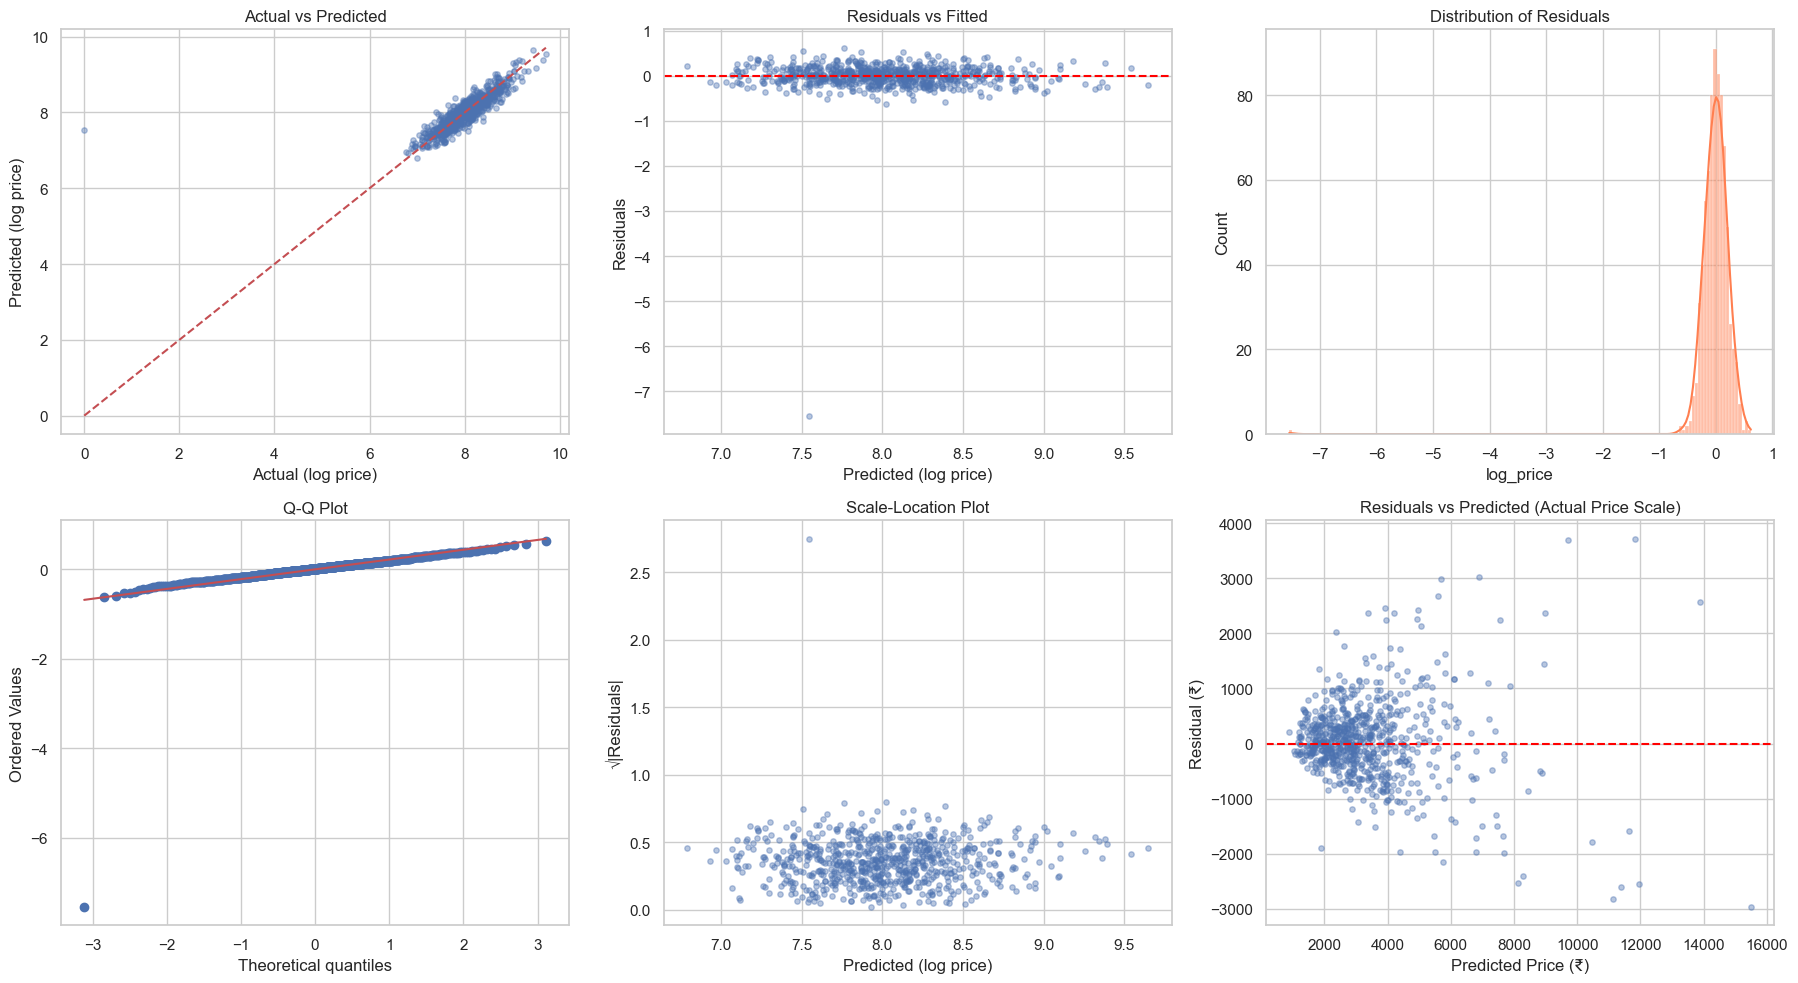

              feature  coefficient
52   room_Entire home     0.316050
59        prop_Studio    -0.283425
58     prop_Penthouse     0.241047
51          city_Pune    -0.234946
48           city_Goa     0.224750
54   room_Shared room    -0.219776
36           has_pool     0.191905
55     prop_Apartment    -0.183239
3           bathrooms     0.170788
50        city_Mumbai     0.164847
2            bedrooms     0.164025
60         prop_Villa     0.160819
24     bed_bath_ratio     0.121376
49        city_Jaipur    -0.108496
53  room_Private room    -0.096274


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

residuals = y_test - y_pred_log  # work in log-scale, the scale the model was trained on

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Actual vs Predicted
axes[0,0].scatter(y_test, y_pred_log, alpha=0.4, s=15)
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0,0].set_xlabel('Actual (log price)')
axes[0,0].set_ylabel('Predicted (log price)')
axes[0,0].set_title('Actual vs Predicted')

# 2. Residuals vs Fitted
axes[0,1].scatter(y_pred_log, residuals, alpha=0.4, s=15)
axes[0,1].axhline(0, color='red', linestyle='--')
axes[0,1].set_xlabel('Predicted (log price)')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Residuals vs Fitted')

# 3. Histogram/KDE of residuals
sns.histplot(residuals, kde=True, ax=axes[0,2], color='coral')
axes[0,2].set_title('Distribution of Residuals')

# 4. Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot')

# 5. Scale-Location plot (spread of residuals)
sqrt_abs_resid = np.sqrt(np.abs(residuals))
axes[1,1].scatter(y_pred_log, sqrt_abs_resid, alpha=0.4, s=15)
axes[1,1].set_xlabel('Predicted (log price)')
axes[1,1].set_ylabel('√|Residuals|')
axes[1,1].set_title('Scale-Location Plot')

# 6. Residuals vs Actual price (business scale) to sanity-check real errors
axes[1,2].scatter(y_pred_actual, y_test_actual - y_pred_actual, alpha=0.4, s=15)
axes[1,2].axhline(0, color='red', linestyle='--')
axes[1,2].set_xlabel('Predicted Price (₹)')
axes[1,2].set_ylabel('Residual (₹)')
axes[1,2].set_title('Residuals vs Predicted (Actual Price Scale)')

plt.tight_layout()
plt.show()

# Coefficient magnitudes — which features drive the model most
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print(coef_df.head(15))